# General stuff

In [28]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import pandas as pd
import random
import seaborn as sns
from torch import nn

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.image as mpimg
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


from belearn.viz.viz import Viz
from belearn.dataset.dataset import BE_Dataset
from belearn.functions.sho import SHO_nn

from autophyslearn.spectroscopic.nn import Multiscale1DFitter, Model
from autophyslearn.postprocessing.complex import ComplexPostProcessor

from m3util.ml.rand import set_seeds
from m3util.viz.style import set_style
from m3util.viz.printing import printer
from m3util.viz.layout import inset_connector, add_box, imagemap, FigDimConverter, subfigures
from m3util.viz.text import set_sci_notation_label, labelfigs, bring_text_to_front, number_to_letters


printing = printer(basepath = './Figures/')


set_style("printing")
set_seeds(seed=42)

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
printing set for seaborn
Pytorch seed was set to 42
Numpy seed was set to 42
tensorflow seed was set to 42


In [29]:
# Specify the filename and the path to save the file
filename = "data_raw.h5"
save_path = "./Data"

data_path = save_path + "/" + filename



# instantiate the dataset object7
dataset = BE_Dataset(data_path)

#dataset = BE_Dataset(data_path)


# print the contents of the file
dataset.print_be_tree

/
├ Measurement_000
  ---------------
  ├ Channel_000
    -----------
    ├ Bin_FFT
    ├ Bin_Frequencies
    ├ Bin_Indices
    ├ Bin_Step
    ├ Bin_Wfm_Type
    ├ Excitation_Waveform
    ├ Noise_Floor
    ├ Noisy_Data_1
    ├ Noisy_Data_2
    ├ Noisy_Data_3
    ├ Noisy_Data_4
    ├ Noisy_Data_5
    ├ Noisy_Data_6
    ├ Noisy_Data_7
    ├ Noisy_Data_8
    ├ Position_Indices
    ├ Position_Values
    ├ Raw_Data
    ├ Raw_Data_Reshaped
    ├ Spatially_Averaged_Plot_Group_000
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spatially_Averaged_Plot_Group_001
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spectroscopic_Indices
    ├ Spectroscopic_Values
    ├ UDVS
    ├ UDVS_Indices
  ├ Raw_D

In [30]:
# instantiates the visualization object
BE_viz = Viz(dataset, printing, verbose=True)
BE_viz.SHO_preprocessing()
BE_viz.SHO_Scaler()

Accessing data at: Raw_Data-SHO_Fit_000/Fit


# Figure 1

pixel:  3174
voltagestep:  348


/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/m3util/viz/layout.py:284: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=wspace, hspace=hspace)
/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


./Figures/Figure_2_raw_be_experiment_test.png
./Figures/Figure_2_raw_be_experiment_test.svg


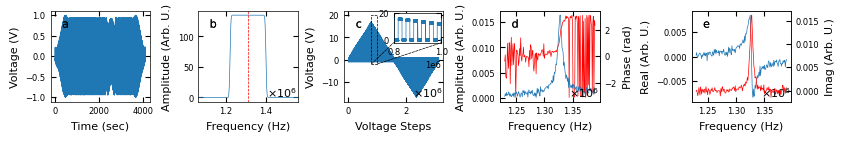

In [4]:
fig = BE_viz.raw_be(dataset, filename="Figure_2_raw_be_experiment_test")

In [5]:
axes = fig.axes

In [6]:
axes

[<Axes: xlabel='Time (sec)', ylabel='Voltage (V)'>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Amplitude (Arb. U.)'>,
 <Axes: xlabel='Voltage Steps', ylabel='Voltage (V)'>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Amplitude (Arb. U.)'>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Real (Arb. U.)'>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Phase (rad)'>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Imag (Arb. U.)'>]

/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


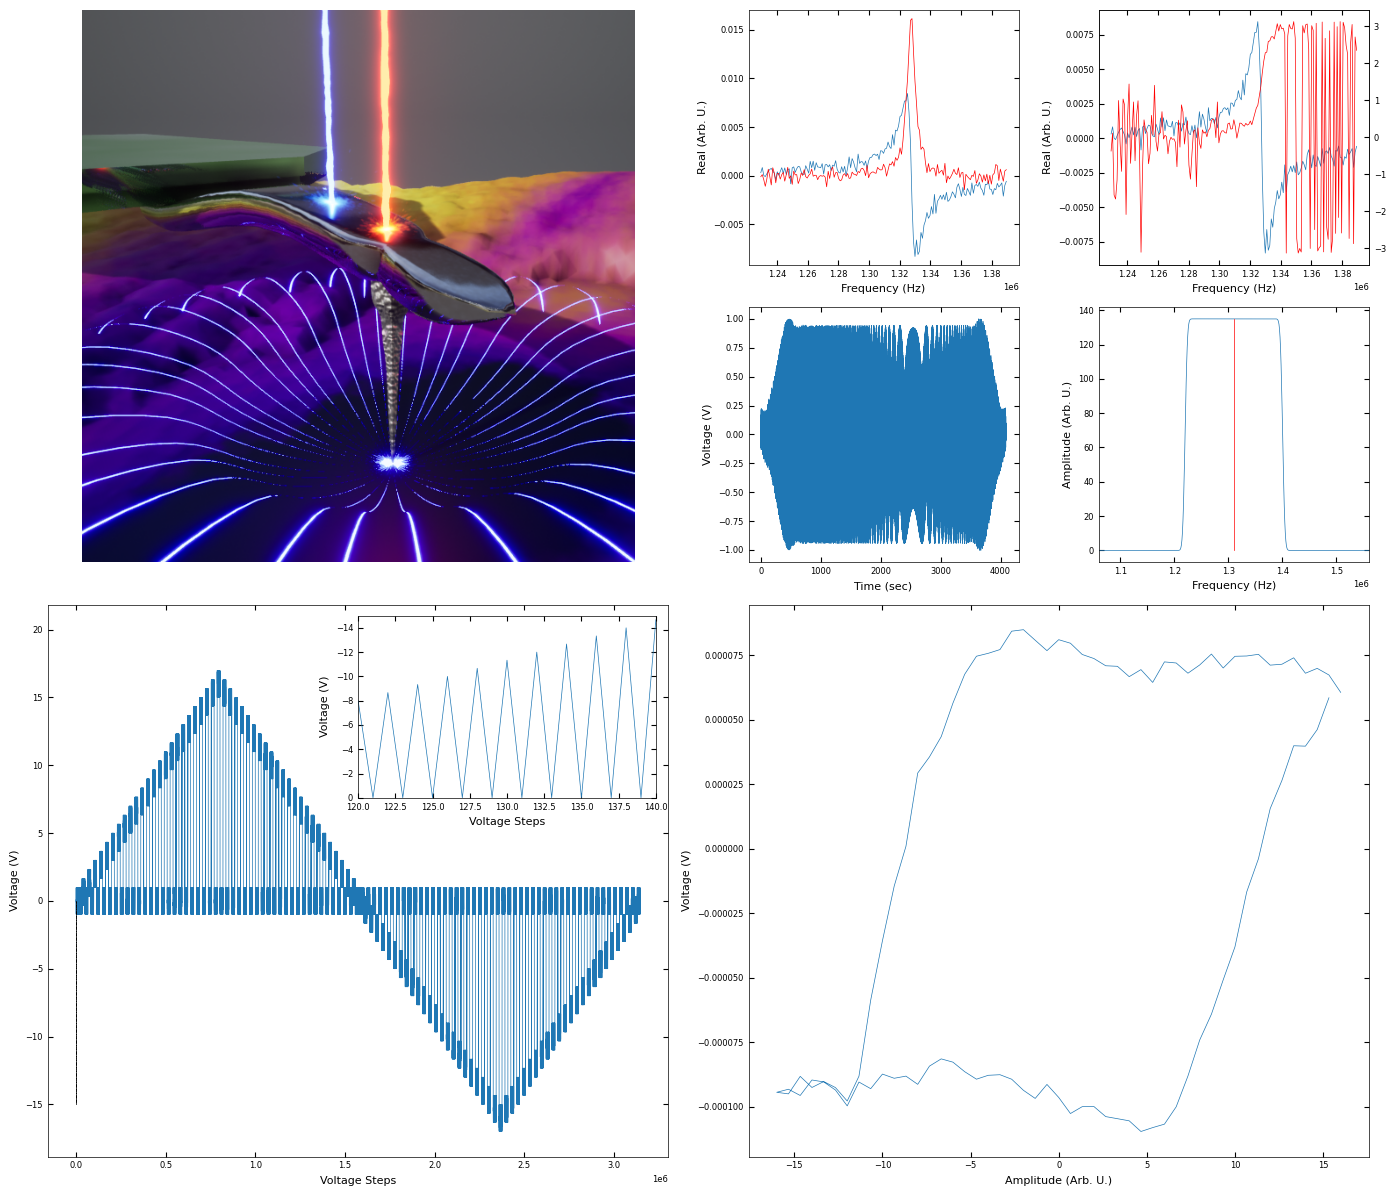

In [7]:
def copy_axes_properties(source_ax, target_ax, secondary_ax=None, type_ax=None):
    """Copy properties and data from source_ax to target_ax."""
    target_ax.set_xlabel(source_ax.get_xlabel())
    target_ax.set_ylabel(source_ax.get_ylabel())
    target_ax.set_xlim(source_ax.get_xlim())
    target_ax.set_ylim(source_ax.get_ylim())
        
    for line in source_ax.get_lines():
        target_ax.plot(line.get_xdata(), line.get_ydata(), color=line.get_color())
        
    if secondary_ax != None:
        if type_ax == 'twin':
            ax_twin = target_ax.twinx()
            for line in secondary_ax.get_lines():
                ax_twin.plot(line.get_xdata(), line.get_ydata(), color=line.get_color())
        elif type_ax == 'same':
            for line in secondary_ax.get_lines():
                target_ax.plot(line.get_xdata(), line.get_ydata(), color=line.get_color())
                
                max_x_lim = max(source_ax.get_xlim()[1], secondary_ax.get_xlim()[1])
                min_x_lim = min(source_ax.get_xlim()[0], secondary_ax.get_xlim()[0])
                max_y_lim = max(source_ax.get_ylim()[1], secondary_ax.get_ylim()[1])
                min_y_lim = min(source_ax.get_ylim()[0], secondary_ax.get_ylim()[0])
                target_ax.set_xlim((min_x_lim, max_x_lim))
                target_ax.set_ylim((min_y_lim, max_y_lim))
        else:
            ax_new = target_ax.inset_axes([0.5, 0.65, 0.48, 0.33])
            x_start = 120
            x_end = 140
            ax_new.plot(BE_viz.hysteresis_waveform)
            ax_new.set_xlim(x_start, x_end)
            ax_new.set_ylim(0, -15)

            # drows the inset connector
            inset_connector(
                source_ax,
                target_ax,
                ax_new,
                [(x_start, 0), (x_end, 0)],
                [(x_start, 0), (x_end, 0)],
                color="k",
                linestyle="--",
                linewidth=0.5,
            )

            # adds a box on the figure
            add_box(
                target_ax,
                (x_start, 0, x_end, -15),
                edgecolor="k",
                linestyle="--",
                facecolor="none",
                linewidth=0.5,
                zorder=10,
            )
            ax_new.set_xlabel("Voltage Steps")
            ax_new.set_ylabel("Voltage (V)")

# Create a figure
fig = plt.figure(figsize=(14, 12))

# Define the GridSpec layout
gs = GridSpec(4, 4, figure=fig)

order = [['AFM'], [1], [0], [4, 'same', 6], [4, 'twin', 5], [2, 'inset', 3], ['hysteresis_loop']]

# List of axes indices in GridSpec for each subplot
subplot_specs = [(0, 2, 0, 2), # a (3D AFM)
                 (1, 2, 3, 4), # b (resonance frequency)
                 (1, 2, 2, 3), # c (waveform)
                 (0, 1, 2, 3), # d (real/imag)
                 (0, 1, 3, 4), # e (amp/phase)
                 (2, 4, 0, 2), # f (triangular waveform)
                 (2, 4, 2, 4)] # g (hysteresis)

# Create and set up subplots
for i, (r_start, r_end, c_start, c_end) in enumerate(subplot_specs):
    ax = fig.add_subplot(gs[r_start:r_end, c_start:c_end])
    if i < len(axes):
        idx = order[i]
        if idx[0] == 'AFM':
            image_path = "./assets/AFM_field.png"
            img = mpimg.imread(image_path)
            ax.imshow(img)
            ax.axis('off')  # Turn off axis for image subplot
        elif idx[0] == 'hysteresis_loop':
            raw_hysteresis_loop, voltage = BE_viz.get_hysteresis(
                                loop_interpolated=True, plotting_values=True)
            row = random.randint(0, 59)
            col = random.randint(0, 59)
            cycle = random.randint(0, 3)
            ax.plot(voltage.squeeze()*-1,
                       raw_hysteresis_loop[row, col, cycle, :].squeeze())
            ax.set_xlabel("Amplitude (Arb. U.)")
            ax.set_ylabel("Voltage (V)")
        elif len(idx) == 1:
            copy_axes_properties(axes[idx[0]], ax)
        else:
            copy_axes_properties(axes[idx[0]], ax, axes[idx[2]], idx[1])
            

# Adjust the spacing between the plots as needed
plt.tight_layout()

# Show the layout
plt.show()

# Figure 2 is a diagram of the neural network model structures and is not reproduced in code

# Figure 3

In [8]:
def SHO_fit_func_nn(params,
                    wvec_freq,
                    device='cpu'):
    """_summary_

    Returns:
        _type_: _description_
    """

    Amp = params[:, 0].type(torch.complex128)
    w_0 = params[:, 1].type(torch.complex128)
    Q = params[:, 2].type(torch.complex128)
    phi = params[:, 3].type(torch.complex128)
    wvec_freq = torch.tensor(wvec_freq)

    Amp = torch.unsqueeze(Amp, 1)
    w_0 = torch.unsqueeze(w_0, 1)
    phi = torch.unsqueeze(phi, 1)
    Q = torch.unsqueeze(Q, 1)

    wvec_freq = wvec_freq.to(device)

    numer = Amp * torch.exp((1.j) * phi) * torch.square(w_0)
    den_1 = torch.square(wvec_freq)
    den_2 = (1.j) * wvec_freq.to(device) * w_0 / Q
    den_3 = torch.square(w_0)

    den = den_1 - den_2 - den_3

    func = numer / den

    return func

In [9]:
LSQF_ = {'resampled': True,
                'raw_format': 'complex',
                'fitter': 'LSQF',
                'scaled': False,
                'output_shape': 'index',
                'measurement_state': 'all',
                'resampled_bins': 165,
                'LSQF_phase_shift': 0, #1.5707963267948966,
                'NN_phase_shift': None,
                'noise': 0}

LSQF_Params = BE_viz.SHO_fit_results(state = LSQF_)

Pytorch seed was set to 42
Numpy seed was set to 42
tensorflow seed was set to 42
Using GPU NVIDIA GeForce RTX 3090

            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = False
            Raw Format = complex
            Fitter = LSQF
            Scaled = False
            Output Shape = pixels
            Measurement State = all
            Resample Resampled = False
            Resample Bins = 165
            LSQF Phase Shift = None
            NN Phase Shift = None
            Noise Level = 0
            Loop Interpolated = False
            


/home/julian/AutoPhysLearn/src/autophyslearn/spectroscopic/nn.py:779: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(model_path,map_loca

data type <class 'numpy.ndarray'>
(1382400, 4)
(1382400, 4)
./Figures/Figure_15_NN_Switching_Maps_test.png
./Figures/Figure_15_NN_Switching_Maps_test.svg


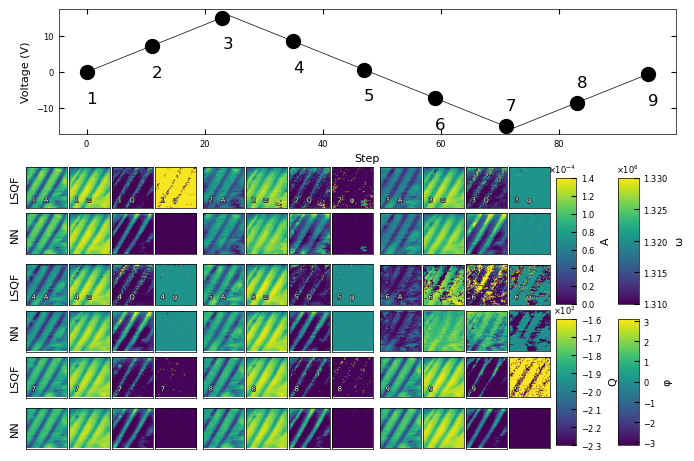

In [12]:
set_seeds(seed=42)
device = torch.device("cuda:0")

postprocessor = ComplexPostProcessor(BE_viz, device=device)

model_ = Multiscale1DFitter(SHO_fit_func_nn, # function 
                            BE_viz.frequency_bin, # x data
                            2, # input channels
                            4, # output channels
                            BE_viz.SHO_scaler, 
                            postprocessor)

# instantiate the model
model = Model(model_, BE_viz, training=False, model_basename="SHO_Fitter_original_data")

model.load(
    #"./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_optimizer_Adam_epoch_4_train_loss_0.03404089391780737.pth"
    "./Trained Models/SHO Fitter/2024-09-23_14-36-21_nn_benchmarks_noise/SHO_Fitter_model_optimizer_Adam_epoch_4_train_loss_0.040321211942850994.pth"
)

# model.load_state_dict(torch.load("./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_optimizer_Trust Region CG_epoch_599_train_loss_0.005903387442231178.pth"))

X_data, Y_data = BE_viz.NN_data()

# you can view the test and training dataset by replacing X_data with X_test or X_train
pred_data, scaled_param, parm = model.predict(X_data)

fig = BE_viz.SHO_switching_maps_test([LSQF_Params, parm],labels = ["LSQF", "NN"], filename="Figure_15_NN_Switching_Maps_test")

In [13]:
axes = fig.axes

./Figures/Figure_16_Violin_2.png
./Figures/Figure_16_Violin_2.svg


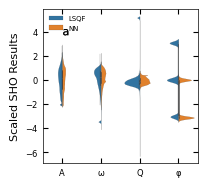

In [14]:
true_state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
    "measurement_state": "all",
}


#fig = BE_viz.violin_plot_comparison(true_state, model, X_data, filename="Figure_16_Violin") 
fig = BE_viz.violin_plot_comparison_SHO(true_state, model, X_data, filename="Figure_16_Violin_2") 

In [15]:
axes.extend(fig.axes)


            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = True
            Raw Format = complex
            Fitter = LSQF
            Scaled = True
            Output Shape = index
            Measurement State = all
            Resample Resampled = True
            Resample Bins = 165
            LSQF Phase Shift = 1.5707963267948966
            NN Phase Shift = 1.5707963267948966
            Noise Level = 0
            Loop Interpolated = False
            

            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None

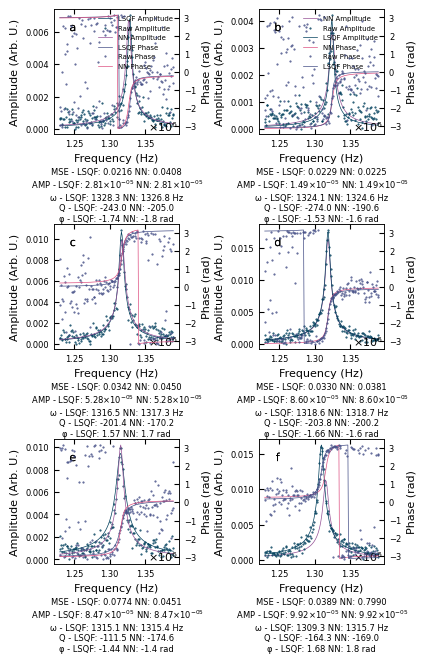

In [16]:
# sets the phase shift of the dataset
BE_viz.NN_phase_shift = np.pi/2
BE_viz.LSQF_phase_shift = np.pi/2
BE_viz.measurement_state = "all"

# sets the true state which to compare the results.
true_state = {
    "fitter": "LSQF",
    "raw_format": "complex",
    "resampled": True,
    "scaled": True,
    "output_shape": "index",
    "measurement_state": "all",
}

# sets the state of the output data
out_state = {"scaled": True, "raw_format": "magnitude spectrum"}

# sets the number of examples to get
n = 1

##### the problem is that prediction is dict ######

LSQF = BE_viz.get_best_median_worst(
    true_state,
    prediction={"fitter": "LSQF"},
    model = model,
    out_state=out_state,
    SHO_results=True,
    n=n,
)

NN = BE_viz.get_best_median_worst(
    true_state, prediction=model, out_state=out_state, SHO_results=True, n=n
)

data = (LSQF, NN)
names = ["LSQF", "NN"]



fig = BE_viz.SHO_Fit_comparison(
    data,
    names,
    model_comparison=[model, {"fitter": "LSQF"}],
    out_state=out_state,
    filename="Figure_14_LSQF_NN_bmw_comparison_2",
    # display_results = None
    
)

In [17]:
axes.extend(fig.axes)


            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = True
            Raw Format = complex
            Fitter = LSQF
            Scaled = True
            Output Shape = index
            Measurement State = all
            Resample Resampled = True
            Resample Bins = 165
            LSQF Phase Shift = 1.5707963267948966
            NN Phase Shift = 1.5707963267948966
            Noise Level = 0
            Loop Interpolated = False
            

            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None

/tmp/ipykernel_141937/197215302.py:663: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = True
            Raw Format = complex
            Fitter = LSQF
            Scaled = True
            Output Shape = index
            Measurement State = all
            Resample Resampled = True
            Resample Bins = 165
            LSQF Phase Shift = 1.5707963267948966
            NN Phase Shift = 1.5707963267948966
            Noise Level = 0
            Loop Interpolated = False
            

            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None

/tmp/ipykernel_141937/197215302.py:663: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = True
            Raw Format = complex
            Fitter = LSQF
            Scaled = True
            Output Shape = index
            Measurement State = all
            Resample Resampled = True
            Resample Bins = 165
            LSQF Phase Shift = 1.5707963267948966
            NN Phase Shift = 1.5707963267948966
            Noise Level = 0
            Loop Interpolated = False
            

            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None

...

/tmp/ipykernel_141937/197215302.py:663: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



            Dataset = BE_Dataset(file='./Data/data_raw.h5', noise=0, resampled_bins=None, resampled_data=None, datafed=None, basegroup='/Measurement_000/Channel_000', raw_data_path='Raw_Data_SHO_Fit/Raw_Data-SHO_Fit_000', measurement_data_path='Measurement_Data/Measurement_Data-000', measurement='Measurement_000', SHO_fit_relative_base_path='SHO_Fit_000', SHO_hysteresis_loop_fit_name='Fit-Loop_Fit_000', SHO_hysteresis_loop_guess_name='Guess-Loop_Fit_000')
            Resample = True
            Raw Format = complex
            Fitter = LSQF
            Scaled = True
            Output Shape = index
            Measurement State = all
            Resample Resampled = True
            Resample Bins = 165
            LSQF Phase Shift = 1.5707963267948966
            NN Phase Shift = 1.5707963267948966
            Noise Level = 0
            Loop Interpolated = False
            


/tmp/ipykernel_141937/197215302.py:663: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_141937/197215302.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_141937/197215302.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_141937/197215302.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_141937/197215302.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_141937/197215302.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results mi

(1382400, 4)
(1382400, 4)


/tmp/ipykernel_141937/197215302.py:438: UserWarning: Adding colorbar to a different Figure <Figure size 2400x2400 with 10 Axes> than <Figure size 650x439 with 72 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0],
/tmp/ipykernel_141937/197215302.py:455: UserWarning: Adding colorbar to a different Figure <Figure size 2400x2400 with 10 Axes> than <Figure size 650x439 with 72 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0],
/tmp/ipykernel_141937/197215302.py:461: UserWarning: Adding colorbar to a different Figure <Figure size 2400x2400 with 10 Axes> than <Figure size 650x439 with 72 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0],
/tmp/ipykernel_141937/197215302.py:467: UserWarning: Adding colorbar to a different Figure <Figure size 2400x2400 with 10 Axes> than <Figure size 650x439 with 7

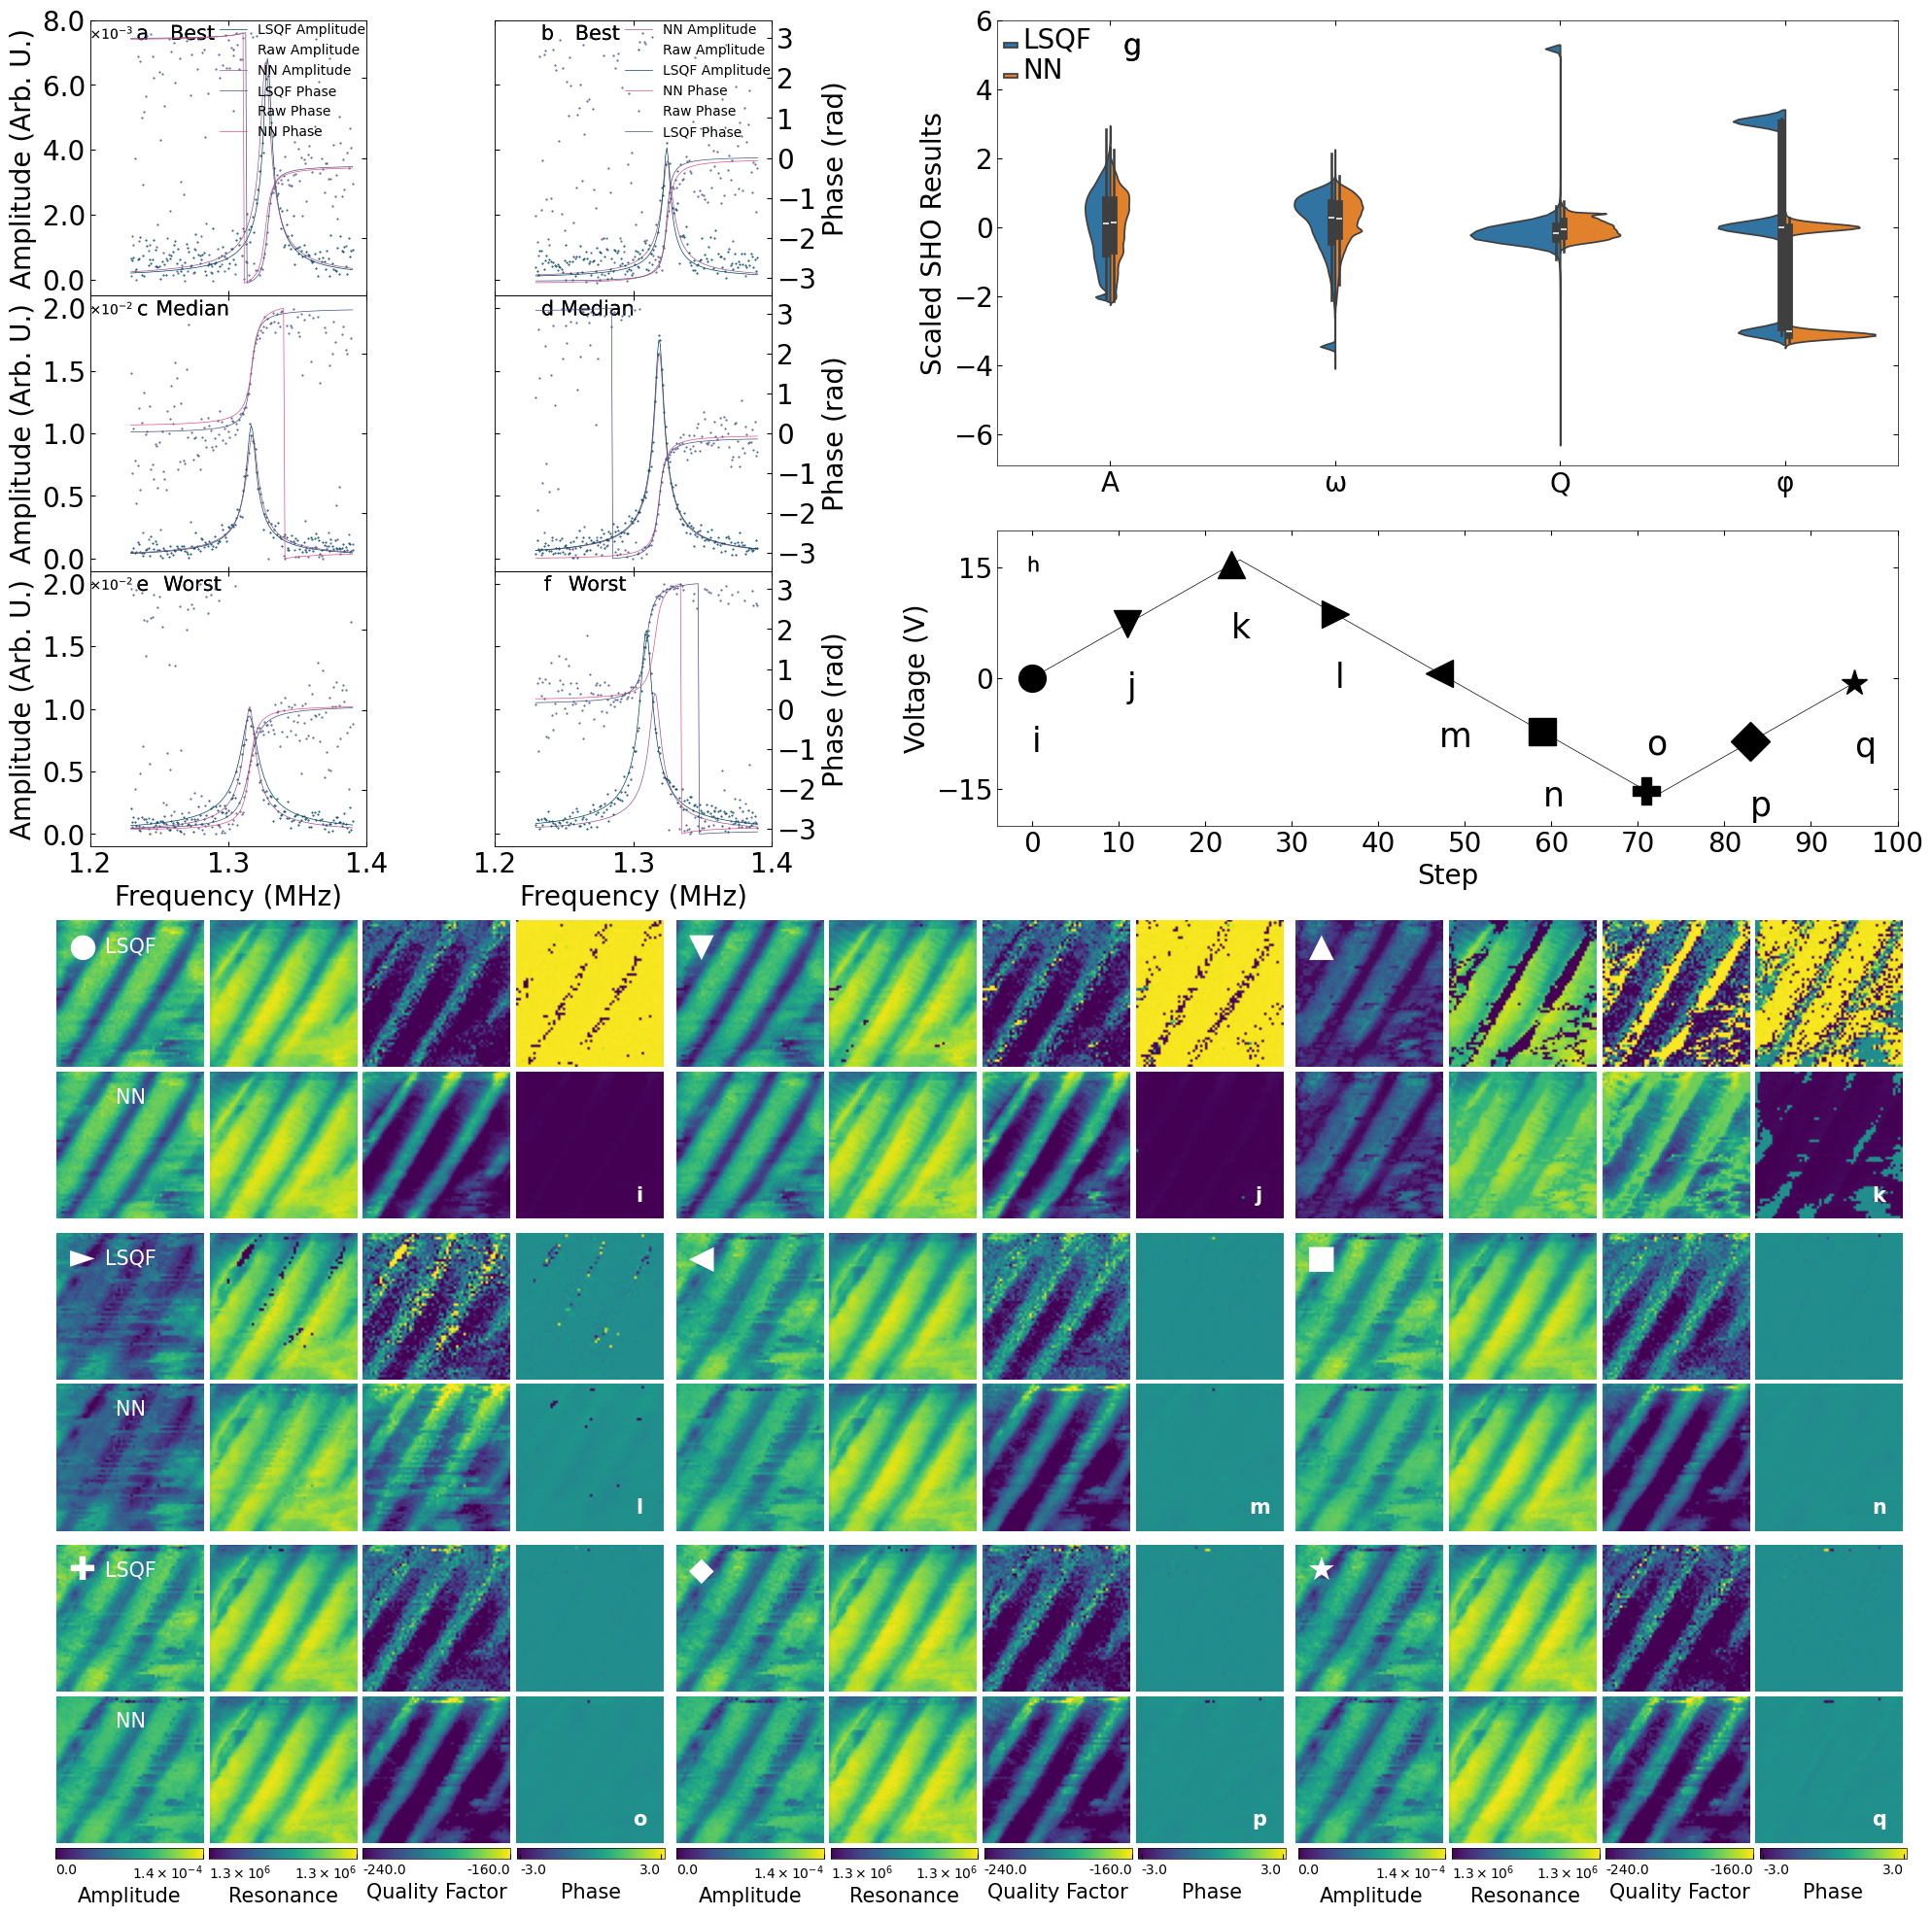

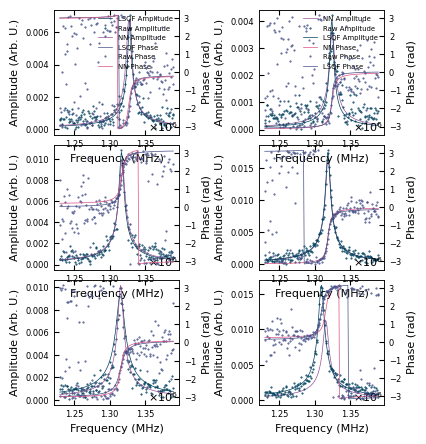

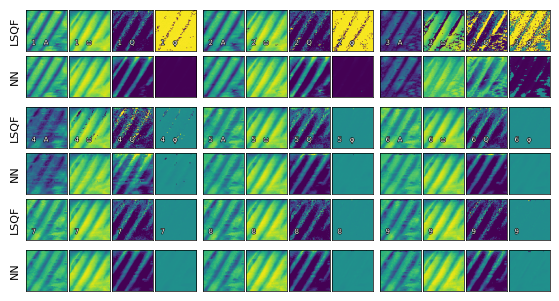

./Figures/Figure_3_test2.png
./Figures/Figure_3_test2.svg


In [33]:
def y_formatter(y, pos):
    return f"{y * 1e3:.1f}"  # Multiply by 1e3 to show scaled values

def copy_axes_properties(row,col,source_ax, target_ax, secondary_ax, ax_lims):
    """Copy properties and data from source_ax to target_ax."""
    # Copy basic properties
    target_ax.set_xlim([1.2,1.4])

    if row == 2: # if i in [4,5]:
        target_ax.set_xlabel('Frequency (MHz)',fontsize=20)
    else:
        target_ax.set_xlabel("")
        #target_ax.set_xticks([])
        target_ax.xaxis.set_ticklabels([])

    if col == 0:    
        target_ax.set_ylabel(source_ax.get_ylabel(),fontsize=20)
    else:
        target_ax.set_ylabel("")
        target_ax.yaxis.set_ticklabels([])

        
    if row == 0:
        target_ax.set_ylim([-0.5e-3,8.0e-3])
    elif row == 1: 
        target_ax.set_ylim([-0.1e-2,2.1e-2])
    elif row == 2: 
        target_ax.set_ylim([-0.1e-2,2.1e-2])    
    
    target_ax.set_title(source_ax.get_title())

    # Copy lines from the primary axis
    for line in source_ax.get_lines():
        label = line.get_label() if line.get_label() != '_nolegend_' else None
        # Copying line properties like color, linestyle, marker, etc.
        target_ax.plot(line.get_xdata()/1e6, line.get_ydata(), color=line.get_color(),
                       linestyle=line.get_linestyle(), marker=line.get_marker(), label=label)
        
    # Handle twin axes if present
    #if secondary_ax:
    ax_twin = target_ax.twinx()
    ax_twin.set_ylim(secondary_ax.get_ylim())

    if col == 0: #if i % 2 == 0: 
        ax_twin.set_ylabel("")
        ax_twin.yaxis.set_ticklabels([])
        
        set_sci_notation_label(
                target_ax, corner="top left", axis="y", stroke_color="w", linewidth=0.5,
                textsize = 10, offset_points = (0,30)
            )
    else:
        ax_twin.set_ylabel(secondary_ax.get_ylabel(),fontsize = 20)
        ax_twin.set_yticks([-3,-2,-1,0,1,2,3])


    for line in secondary_ax.get_lines():
        label = line.get_label() if line.get_label() != '_nolegend_' else None
        # Copying line properties for the twin axis
        ax_twin.plot(line.get_xdata()/1e6, line.get_ydata(), color=line.get_color(),
                        linestyle=line.get_linestyle(), marker=line.get_marker(), label=label)
    
    
    target_ax.tick_params(axis='x',labelsize=20)
    target_ax.tick_params(axis='y',labelsize=20)
    if row == 0 and col == 0: 
        target_ax.yaxis.set_major_formatter(FuncFormatter(y_formatter))

    ax_twin.tick_params(axis='x',labelsize=20)

    ax_twin.tick_params(axis='y',labelsize=20)
    
    plt.tight_layout()

# Create a figure

fig = plt.figure(figsize=(24, 24))


# Define the GridSpec layout
gs = GridSpec(60, 40, figure=fig)

order = [['SHO_fit_comp'],
         ['violin'],
         ['voltage_curve'],
         ['switching_maps']
        ]



subplot_specs = [(0, 30, 0, 20 ), # top left: SHO fit comparisons 
                 (0, 15, 20, 40), # g
                 (17, 27, 20, 40), # h
                 (30, 80, 0, 60), #bottom 
                ]

# define flags for testing to only render certain plots
# maybe delete them now that it works? 
renderViolin = True
renderVoltage = True
renderSwitchingMaps = True
renderBMWComp = True
# Create and set up subplots
for i, (r_start, r_end, c_start, c_end) in enumerate(subplot_specs):
    ax = fig.add_subplot(gs[r_start:r_end, c_start:c_end])
    if i < len(axes):
        idx = order[i]
        if idx[0] == 'violin':
            if renderViolin: 
                df = pd.DataFrame()

                # scales the parameters
                scaled_param = BE_viz.SHO_scaler.transform(parm)

                # gets the parameters from the SHO LSQF fit
                true = BE_viz.SHO_fit_results(phase_shift=0).reshape(-1, 4)

                # Builds the dataframe for the violin plot
                true_df = pd.DataFrame(
                    true, columns=["Amplitude", "Resonance", "Q-Factor", "Phase"]
                )
                predicted_df = pd.DataFrame(
                    scaled_param, columns=["Amplitude",
                                        "Resonance", "Q-Factor", "Phase"]
                )

                # merges the two dataframes
                df = pd.concat((true_df, predicted_df))

                # adds the labels to the dataframe
                names = [true, scaled_param]
                names_str = ["LSQF", "NN"]
                labels = ["A", "\u03C9", "Q", "\u03C6"]

                # adds the labels to the dataframe
                for j, name in enumerate(names):
                    for i, label in enumerate(labels):
                        dict_ = {
                            "value": name[:, i],
                            "parameter": np.repeat(label, name.shape[0]),
                            "dataset": np.repeat(names_str[j], name.shape[0]),
                        }

                        df = pd.concat((df, pd.DataFrame(dict_)))
                
                # Reset index to handle potential duplicated columns or indices
                df = df.reset_index(drop=False)
                
                # plots the data
                sns.violinplot(
                    data=df, x="parameter", y="value", hue="dataset", split=True, ax=ax
                )

                # labels the figure and does some styling
                labelfigs(ax, string_add = 'g', loc ='tl',size=22, style="b", inset_fraction=(0.05,0.15))

                ax.set_ylabel("Scaled SHO Results",fontsize=20)
                ax.set_xlabel("")
                
                ax.tick_params(axis='x',labelsize=20)
                ax.tick_params(axis='y',labelsize=20)
                ax.set_yticks(np.linspace(-6,6,7))


                # Get the legend associated with the plot
                legend = ax.get_legend()
                legend.set_title("")
                plt.setp(legend.get_texts(), fontsize=20) # Set the label size
                
        elif idx[0] == "voltage_curve":
            if renderVoltage:
                voltage = np.swapaxes(np.atleast_2d(BE_viz.get_voltage), 0, 1).astype(np.float64)
                voltage = BE_viz.roll_hysteresis(voltage)

                # # Get indices of the voltage steps to plot
                inds = np.linspace(0, len(voltage) - 1, 9, dtype=int)

                # plots the voltage
                ax.plot(voltage, "k")
                ax.set_ylabel("Voltage (V)",fontsize=20)
                ax.set_xlabel("Step",fontsize=20)
                ax.set_xticks(np.linspace(0,100,11))
                ax.set_xlim([-4,100])
                ax.set_ylim([-20,20])
                ax.set_yticks([-15,0,15])
                ax.tick_params(axis='x',labelsize=20)
                ax.tick_params(axis='y',labelsize=20)

                label_marker_symbols_for_plt = ["o", "v", "^", ">", "<", "s","P", "D","*"]

                
                # Plot the data with different markers
                for i, ind in enumerate(inds):
                    # this adds the labels to the graphs
                
                    ax.plot(ind, voltage[ind], label_marker_symbols_for_plt[i], 
                            color="k", markersize=20)
                    vshift = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.25

                    # positions the location of the labels
                    if voltage[ind] - vshift - 0.15 < ax.get_ylim()[0]:
                        vshift = -vshift / 2

                    # # adds the text to the graphs
                    ax.text(ind, voltage[ind] - vshift,
                            number_to_letters(i + 8), color="k", fontsize=25)
                    
                    # labelfigs(ax, number = i+8, loc = 'tl', size=20,style='b',
                    #           inset_fraction=(ind,voltage[ind]-vshift))
                plt.tight_layout()
                
                labelfigs(ax,
                    string_add='h',
                    loc ='tl',
                    size=15, #22
                    inset_fraction=(0.12,0.04),
                    style = 'b'
                    )

        elif idx[0] == "switching_maps": # see BE_viz.SHO_switching_maps_test for reference
            if renderSwitchingMaps:
                
                clims=[
                    (0, 1.4e-4),  # amplitude
                    (1.31e6, 1.33e6),  # resonance frequency
                    (-230, -160),  # quality factor
                    (-np.pi, np.pi), # phase
                ]  
            
                number_of_steps = 9
                SHO_ = [LSQF_Params,parm]
                comp_number = len(SHO_)

                rows = np.ceil(number_of_steps * comp_number / 3)
                cols = 3
                
                
                fig_width = 6.5
                intra_gap=0.02  # gap between the graphs,
                inter_gap=0.05  # gap between the graphs,
                cbar_gap=0.4  # gap between the graphs of colorbars
                cbar_space=1.3  # space on the right where the cbar is not
                voltage_plot_height=1.25  # height of the voltage plot
                colorbars = True

                        
                # calculates the size of the embedding image
                embedding_image_size = (
                    fig_width
                    - (inter_gap * (cols - 1))
                    - intra_gap * 3 * cols
                    - cbar_space * colorbars
                ) / (cols * 4)
                
                
                # calculates the figure height based on the image details
                fig_height = (
                    rows * (embedding_image_size + inter_gap)
                    + voltage_plot_height
                    + 0.33
                    + inter_gap * (comp_number - 1)
                )

                # defines a scalar to convert inches to relative coordinates
                fig_scalar = FigDimConverter((fig_width, fig_height))
                fig = plt.figure(figsize=(fig_width, fig_height))

                ax2 = [] 
                
                    # Define the position and size of the voltage plot
                pos_inch = [
                    0.33,
                    fig_height - voltage_plot_height,
                    fig_width - 0.33,
                    voltage_plot_height,
                ]
                
                # adds the plot for the voltage
                #ax2.append(fig.add_axes(fig_scalar.to_relative(pos_inch)))
                
                #len(ax) here should be 1
                
                
                
                # resets the x0 position for the embedding plots
                pos_inch[0] = 0
                pos_inch[1] -= embedding_image_size + 0.33

    
                # sets the embedding size of the image
                pos_inch[2] = embedding_image_size
                pos_inch[3] = embedding_image_size
                
                    # This makes the figures
                for k, _SHO in enumerate(SHO_):
                    # adds the embedding plots
                    for i in range(number_of_steps):
                        # loops around the amp, phase, and freq
                        for j in range(4):
                            # adds the plot to the figure
                            ax2.append(fig.add_axes(fig_scalar.to_relative(pos_inch)))

                            # adds the inter plot gap
                            pos_inch[0] += embedding_image_size + intra_gap

                        # if the last column in row, moves the position to the next row
                        if (i + 1) % cols == 0 and i != 0:
                            # resets the x0 position for the embedding plots
                            pos_inch[0] = 0

                            # moves the y0 position to the next row
                            pos_inch[1] -= embedding_image_size + inter_gap

                            if (i + 1) % (cols * comp_number) == 0 and comp_number > 1:
                                pos_inch[1] -= inter_gap

                        else:
                            # adds the small gap between the plots
                            pos_inch[0] += inter_gap
              
                
                for k, _SHO in enumerate(SHO_):
                    # converts the data to a numpy array
                    if isinstance(_SHO, torch.Tensor):
                        _SHO = _SHO.detach().numpy()

                    print(_SHO.shape)
                    _SHO = _SHO.reshape(BE_viz.num_pix,
                                        BE_viz.voltage_steps, 4)

                    # get the selected measurement cycle
                    # TODO: maybe don't hardcode cycle=2? 
                    _SHO = BE_viz.get_measurement_cycle(_SHO, cycle=2,axis=1)

                    names = ["A", "\u03C9", "Q", "\u03C6"]

                    for i, ind in enumerate(inds):
                        axis_start = int(
                            (i % cols) * 4
                            + ((i) // cols) * (comp_number * cols * 4)
                            + k * (cols * 4)
                            + 1
                        )

                        # loops around the amp, resonant frequency, and Q, Phase
                        for j in range(4):
                            imagemap(
                                ax2[axis_start + j-1],
                                _SHO[:, ind, j],
                                colorbars=False,
                                cmap="viridis",
                            )

                            if i // rows == 0 and k == 0:
                                labelfigs(
                                    ax2[axis_start + j-1],
                                    string_add=names[j],
                                    loc="cb",
                                    size=5,
                                    inset_fraction=(0.2, 0.2),
                                )

                            ax2[axis_start + j-1].images[0].set_clim(clims[j])

                            if k == 0:
                                labelfigs(
                                    ax2[axis_start + j-1],
                                    string_add=str(i + 1),
                                    size=5,
                                    loc="bl",
                                    inset_fraction=(0.2, 0.2),
                                )

                            if (axis_start + j) % (4 * cols) == 1:
                                ax2[axis_start + j-1].set_ylabel(names_str[k])
                
                label_marker_symbols = ["\u25CF", "\u25BC", "\u25B2", "\u25BA", "\u25C0", "\u25A0","\u271A", "\u25C6","\u2605"]
                label_marker_symbols_counter = 0
                
                
                labels = ['i','j','k','l','m','n','o','p','q']
                label_counter = 0
                names = ['Amplitude', "Resonance","Quality Factor","Phase"]
                clims=[
                        (0, 1.4e-4),  # amplitude
                        (1.31e6, 1.33e6),  # resonance frequency
                        (-240, -160),  # quality factor
                        (-np.pi, np.pi),  # phase
                    ],  # phase limits
                fmt = ScalarFormatter(useMathText=True)
                fmt.set_powerlimits((0, 0))
                # defines a scalar to convert inches to relative coordinates
                fig_scalar = FigDimConverter((1/6, 1/6))
                #fig_scalar = FigDimConverter((fig_width, fig_height))
                
                for row in range(6):
                    for col in range(12):
                        inset_ax = ax.inset_axes([-0.06+(col/11.8)+np.floor(col/4)/256,1-(row+1)/6.1-row/192-np.floor(row/2)/96,1/6.1,1/6.1])

                        inset_ax.imshow(ax2[(12*row)+col].get_images()[0].get_array().data,clim = clims[0][int(np.floor(col % 4))])
                        if col == 0:
                            if row % 2 == 0: 
                                inset_ax.text(30,10,ax2[0].get_ylabel(),color = "white",size=15,ha = "center", va = "center")
                            
                            else:
                                inset_ax.text(30,10,ax2[12].get_ylabel(),color = "white", size=15,ha = "center", va = "center")
                        
                        if row % 2 == 0 and col % 4 == 0: 
                                inset_ax.text(10,10, label_marker_symbols[label_marker_symbols_counter], color = "white", size = 24, ha = "center", va = "center")
                                label_marker_symbols_counter+=1
                        elif row % 2 == 1 and (col + 1) % 4 == 0:
                            inset_ax.text(50,50, labels[label_counter], color = "white", weight = 'bold', size = 15,ha = "center", va = "center")
                            label_counter+=1 
                            
                        if row == 5:
                            
                            
                            fmt = ScalarFormatter(useMathText=True)
                            fmt.set_powerlimits((0, 0))
                                        
                            bar_ax = []
                            pos_inch = [-3.2e-3 + (col/70.5)+np.floor(col/4)/1800, -0.008, 1/73.5, 1/500  ] #fills axes
                          
                            bar_ax.append(ax.inset_axes(fig_scalar.to_relative(pos_inch)))
                            
                            def fmt(x, pos):
                                    a, b = '{:.1e}'.format(x).split('e')
                                    b = int(b)
                                    if abs(b) >2: 
                                        return r'${} \times 10^{{{}}}$'.format(a, b)
                                    else: 
                                        return float(a)*10**b
                                    
                                    
                                    
                            if int(np.floor(col % 4)) == 0:
                                                  
                                cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0], 
                                                    format = FuncFormatter(fmt), 
                                                    ticks = np.linspace(np.min(clims[0][int(np.floor(col % 4))]),
                                                                        np.max(clims[0][int(np.floor(col % 4))]),2), #5
                                                  
                                                    )
                                cbar.ax.get_xticklabels()[0].set_horizontalalignment('left')
                                cbar.ax.get_xticklabels()[1].set_horizontalalignment('right')

                            elif int(np.floor(col % 4)) == 1:
                                
                                def fmt_Resonance(x, pos): #need to display more digits to differentiate the resonance values
                                    a, b = '{:.2e}'.format(x).split('e')
                                    b = int(b)
                                    return r'${} \times 10^{{{}}}$'.format(a, b)
                                    
                                
                                cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0], 
                                                    format = FuncFormatter(fmt), #fmt, 
                                                    ticks = np.linspace(np.min(clims[0][int(np.floor(col % 4))]),
                                                                        np.max(clims[0][int(np.floor(col % 4))]),2) #5
                                                    )
                            elif int(np.floor(col % 4)) == 2:
                                cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0], 
                                                    format = FuncFormatter(fmt), 
                                                    ticks = np.linspace(np.min(clims[0][int(np.floor(col % 4))]),
                                                                        np.max(clims[0][int(np.floor(col % 4))]),2) # 5
                                                    )
                            else:
                                cbar = plt.colorbar(inset_ax.images[0],location = 'bottom', cax = bar_ax[0], 
                                                    format = FuncFormatter(fmt), 
                                                    ticks = np.linspace(-3,3,2)
                                                    ) 
                            
                            cbar.ax.get_xticklabels()[0].set_horizontalalignment('left')
                            cbar.ax.get_xticklabels()[1].set_horizontalalignment('right')
                            cbar.ax.tick_params(labelsize = 10)
                            cbar.set_label(names[int(np.floor(col % 4))],size=15)  # Add a label to the colorbar

                        inset_ax.axis("off")
                
                ax.axis("off")       
            
        else:
            if renderBMWComp:
                ax.axis("off")       

                # Defines the color palettes for the plots
                color_palette = {
                    "LSQF_A": "#003f5c",  # dark blue
                    "LSQF_P": "#444e86",  # bluish purple
                    "NN_A": "#955196",  # purple
                    "NN_P": "#dd5182",  # pinkish red
                    "real": "#ff6e54",  # orange
                    "imag": "#ffa600",  # yellow-orange
                    "mag": "#2f9eaa",  # cyan
                    "phase": "#66c21f",  # green
                }

                # sets the phase shift of the dataset
                BE_viz.NN_phase_shift = np.pi/2
                BE_viz.LSQF_phase_shift = np.pi/2
                BE_viz.measurement_state = "all"

                # sets the true state which to compare the results.
                true_state = {
                    "fitter": "LSQF",
                    "raw_format": "complex",
                    "resampled": True,
                    "scaled": True,
                    "output_shape": "index",
                    "measurement_state": "all",
                }

                # sets the state of the output data
                out_state = {"scaled": True, "raw_format": "magnitude spectrum"}

                #out_state = {"scaled": True, "raw_format": "complex"}


                # sets the number of examples to get
                n = 1

                LSQF = BE_viz.get_best_median_worst(
                    true_state,
                    prediction={"fitter": "LSQF"},
                    out_state=out_state,
                    SHO_results=True,
                    n=n,
                )

                NN = BE_viz.get_best_median_worst(
                    true_state, prediction=model, out_state=out_state, SHO_results=True, n=n
                )
                # from BE_viz.SHO_fit_comparison 
                
                data = (LSQF, NN)
                names = ["LSQF", "NN"]
                model_comparison=[model, {"fitter": "LSQF"}]
                out_state=out_state
                gaps=(0.8, 0.1)
                size=(1.25, 1.25)
                #display_results="all"
                
                # Get the number of fits from the length of the data list
                num_fits = len(data)
                
                # Create subplots for the comparison
                fig_SHO_comp, ax_SHO_comp = subfigures(3, num_fits, gaps=gaps, size=size)
                
                list_ax_ = []
                list_ax1 = [] 
                            
                # Loop through each fit and the associated data
                for step, (data, name) in enumerate(zip(data, names)):
                    # Unpack the data (true, predicted values, indices, etc.)
                    d1, d2, x1, x2, label,full_labels, index1, mse1, params = data

                    # Loop through datasets for comparison (true vs. predicted data)
                    for bmw, (true, prediction, error, SHO, index1) in enumerate(
                        zip(d1, d2, mse1, params, index1)
                    ):
                        # Initialize dictionaries for errors and SHO parameters
                        errors = {}
                        SHOs = {}

                        # Determine the subplot index
                        index = bmw * num_fits + step
                        ax_ = ax_SHO_comp[index]

                        # Plot predicted amplitude and phase
                        ax_.plot(
                            x2,
                            prediction[0].flatten(),
                            color=color_palette[f"{name}_A"],
                            label=f"{name} {label[0]}",
                        )
                        ax1 = ax_.twinx()
                        ax1.plot(
                            x2,
                            prediction[1].flatten(),
                            color=color_palette[f"{name}_P"],
                            label=f"{name} {label[1]}",
                        )

                        # Plot true amplitude and phase
                        ax_.plot(
                            x1,
                            true[0].flatten(),
                            "o",
                            color=color_palette["LSQF_A"],
                            label=f"Raw {label[0]}",
                        )
                        ax1.plot(
                            x1,
                            true[1].flatten(),
                            "o",
                            color=color_palette["LSQF_P"],
                            label=f"Raw {label[1]}",
                        )

                        # Store errors and SHO parameters for the current model
                        errors[name] = error
                        SHOs[name] = SHO
                        
                        
                        if model_comparison[step] is not None:
                            # Get SHO parameters from the comparison model
                            pred_data, params, labels = BE_viz.get_SHO_params(
                                index1, model=model_comparison[step], out_state=out_state
                            )

                            # Determine the color prefix based on model type (NN or LSQF)
                            if isinstance(model_comparison[step], nn.Module):
                                color = "NN"
                            elif isinstance(model_comparison[step], dict):
                                color = "LSQF"

                            # Store errors and SHO parameters for the comparison model
                            errors[color] = BE_viz.get_mse_index(
                                index1, model_comparison[step]
                            )
                            SHOs[color] = np.array(params).squeeze()

                            # Plot the comparison data
                            ax_.plot(
                                x2,
                                pred_data.squeeze()[0].flatten(),
                                color=color_palette[f"{color}_A"],
                                label=f"{color} {labels[0]}",
                            )
                            ax1.plot(
                                x2,
                                pred_data.squeeze()[1].flatten(),
                                color=color_palette[f"{color}_P"],
                                label=f"{color} {labels[1]}",
                            )
                            
                        # Set the x-axis label (Frequency in MHz)
                        ax_.set_xlabel("Frequency (MHz)")
                        
                        if (
                            "raw_format" in out_state.keys()
                            and out_state["raw_format"] == "magnitude spectrum"
                        ):
                            ax_.set_ylabel("Amplitude (Arb. U.)")
                            ax1.set_ylabel("Phase (rad)")
                        else:
                            ax_.set_ylabel("Real (Arb. U.)")
                            ax1.set_ylabel("Imag (Arb. U.)")
                            
                        
                        # Add legend for the last fit
                        if index < num_fits:
                            lines, labels = ax_.get_legend_handles_labels()
                            lines2, labels2 = ax1.get_legend_handles_labels()
                            ax_.legend(lines + lines2, labels + labels2, loc="upper right")
                        
                        set_sci_notation_label(ax_,axis="x",corner = "bottom right")
                        
                        
                        
                        list_ax_.append(ax_)
                        list_ax1.append(ax1)
                        
                        plt.tight_layout()
                    
                        
                # the order of the plots in the paper seem to be different 
                # from the order of the plots in the code.
                # To make them match, put the plots in the following order: 
                axes_index = [0,3,1,4,2,5]
                        
                for row in range(3):
                    for col in range(2):
                        inset_ax = ax.inset_axes([(col/2)-col*0.05,1-(row+1)/3.25,1/3.25,1/3.25])
                        if col == 0: 
                            copy_axes_properties(row,col,list_ax_[axes_index[2*row+col]], inset_ax, list_ax1[axes_index[2*row+col]],list_ax_[axes_index[2*row+col+1]])
                        else:
                            copy_axes_properties(row,col,list_ax_[axes_index[2*row+col]], inset_ax, list_ax1[axes_index[2*row+col]],list_ax_[axes_index[2*row+col-1]])
                    
                        if row == 0:
                            labelfigs(inset_ax,
                                    string_add="Best",
                                    loc ='tl',
                                    size=15,
                                    inset_fraction=(0.05,0.37),
                                    style = 'b',
                                    horizontalalignment = "center"
                                    )
                            
                            # get legend handles and their corresponding labels
                            handles1, labels1 = inset_ax.get_legend_handles_labels()
                            handles2, labels2 = list_ax1[axes_index[2*row+col]].get_legend_handles_labels()
                            
                            inset_ax.legend(handles1 + handles2,labels1+labels2, loc=(0.45,0.55),fontsize = 10)

                        elif row == 1:
                            labelfigs(inset_ax,
                                    string_add="Median",
                                    loc ='tl',
                                    size=15,
                                    inset_fraction=(0.05,0.37),
                                    style = 'b',
                                    horizontalalignment = "center"
                                    )
                            
                        elif row == 2:
                            labelfigs(inset_ax,
                                    string_add="Worst",
                                    loc ='tl',
                                    size=15,
                                    inset_fraction=(0.05,0.37),
                                    style = 'b',
                                    horizontalalignment="center"
                                    )
                            ax.set_xticks([1.2,1.3,1.4])
                            
                        
                        labelfigs(inset_ax,
                            number=2*row+col,
                            loc ='tl',
                            size=15,
                            inset_fraction=(0.05,0.19),
                            style = 'b'
                            )


# Adjust the spacing between the plots as needed
plt.tight_layout()

# Show the layout
plt.show()

BE_viz.Printer.savefig(
                ax.figure, "Figure_3_test2"
            )



# Figure 4

In [38]:
BE_viz.loop_fit_preprocessing()


No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


In [39]:
#from m3_learning.be.loop_fitter import loop_fitting_function_torch
from m3util.ml.optimizers.TrustRegion import TRCG
import torch.optim as optim
from belearn.functions.hysteresis import hysteresis_nn

set_seeds(seed=42)
datafed_path = "2024_SHO_Fitting/Original_NN_SHO_Fitter"
device = 'cuda:0'

data, voltage = BE_viz.get_hysteresis(scaled=True, loop_interpolated = True)
# V = np.swapaxes(np.atleast_2d(dataset.get_voltage), 0, 1).astype(np.float64)


model_ = Multiscale1DFitter(
            #BE_viz.loop_fitting_function_torch, # function 
                hysteresis_nn,  # function

                            voltage[:,0].squeeze(), # x data
#                             V.squeeze(),
                            1, # input channels
                            9, # output parameters
                            BE_viz.loop_param_scaler,
                            loops_scaler=BE_viz.hysteresis_scaler,
                            device=device
                            )

# instantiate the model
model = Model(model_, BE_viz, training=True, model_basename="SHO_Fitter_original_data",
                datafed_path=datafed_path,
                script_path="./Paper_Figures.ipynb",
                device=device)



from sklearn.model_selection import train_test_split


X_train, X_test = train_test_split(data.reshape(-1,96), test_size=0.2, random_state=42, shuffle=True)

X_train = np.atleast_3d(X_train)

optimizer = {
    "name": "TRCG", 
    "optimizer": TRCG,
    "closure_size": 1,
    "cgopttol": 1e-3,
    "c0tr": 0.2,
    "c1tr": 0.25,
    "c2tr": 0.75,
    "t1tr": 0.75,
    "t2tr": 2.0,
    "radius_max": 5.0,  
    "radius_initial": 1.0,
    "radius" : 1.0,
    "device": device,
    "ADAM_epochs": 100}


train =  False # SHOULD BE True but setting to False for now for testing 

if train:
    # fits the model
    model.fit(
        X_train,
        1024,
        optimizer=optimizer,
        epochs = 500,
    )
else:
    model.load(
       # "./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_epoch_5_train_loss_0.0449272525189978.pth"
       "./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_optimizer_Trust Region CG_epoch_499_train_loss_0.005630633379850123.pth"
    )

Pytorch seed was set to 42
Numpy seed was set to 42
tensorflow seed was set to 42
No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


/home/julian/AutoPhysLearn/src/autophyslearn/spectroscopic/nn.py:780: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(model_path,map_loca

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


/home/julian/BEPiezo-Learn/src/belearn/dataset/state.py:1141: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_example['Original Index'] = int(best_example['Original Index'])
/home/julian/BEPiezo-Learn/src/belearn/dataset/state.py:1144: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  worst_example['Original Index'] = int(worst_example['Original Index'])
/home/julian/BEPiezo-Learn/src/belearn/dataset/state.py:1147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returnin

./Figures/Figure_XX_LSQF_NN_bmw_comparison_test3.png
./Figures/Figure_XX_LSQF_NN_bmw_comparison_test3.svg


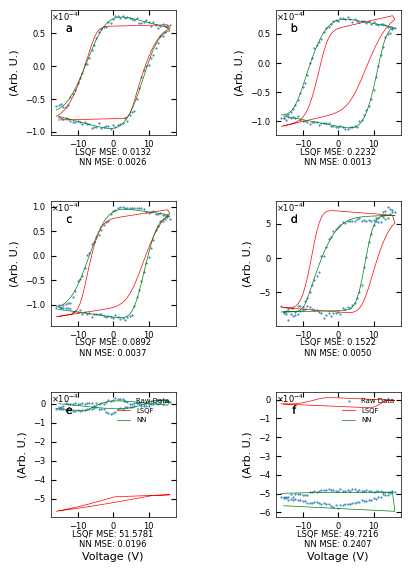

In [7]:
n = 1

data_names = ("LSQF", "NN")

fig = BE_viz.hysteresis_comparison(
    data_names,
    nn_model=model,
    filename="Figure_XX_LSQF_NN_bmw_comparison_test3",
)

In [15]:
axes = fig.axes

In [16]:
axes

[<Axes: xlabel='Voltage (V)', ylabel='(Arb. U.)'>,
 <Axes: xlabel='Voltage (V)', ylabel='(Arb. U.)'>,
 <Axes: ylabel='(Arb. U.)'>,
 <Axes: ylabel='(Arb. U.)'>,
 <Axes: ylabel='(Arb. U.)'>,
 <Axes: ylabel='(Arb. U.)'>]

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
./Figures/Figure_XX_Violin2.png
./Figures/Figure_XX_Violin2.svg


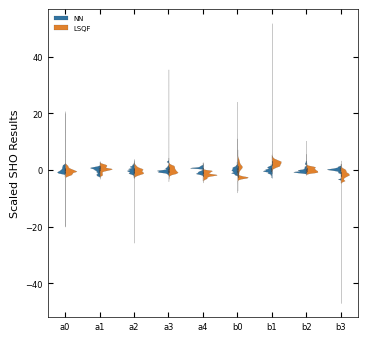

In [37]:
data, voltage = BE_viz.get_hysteresis(scaled=True, loop_interpolated = True)

fig = BE_viz.violin_plot_comparison_hysteresis(model,
                                         torch.atleast_3d(torch.tensor(data.reshape(-1, 96))),
                                         filename="Figure_XX_Violin2") 

In [31]:
ax.plot(fig.axes[0].get_lines()[0].get_xdata(),fig.axes[0].get_lines()[0].get_ydata())

In [26]:
fig.axes[0].get_lines()[0].get_xdata()

array([0., 0.])

AttributeError: 'Figure' object has no attribute 'df'

In [20]:
axes.extend(fig.axes)

In [40]:
data, voltage = BE_viz.get_hysteresis(scaled=True, loop_interpolated = True)
data = torch.atleast_3d(torch.tensor(data.reshape(-1, 96)))

pred_recon, pred_params_scaled, pred_params = model.predict(
    data,
    1024,
    translate_params=False,
    is_SHO=False
)


No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


use printing function
./Figures/Figure_XX_NN_Hysteresis_Maps_test3.png
./Figures/Figure_XX_NN_Hysteresis_Maps_test3.svg


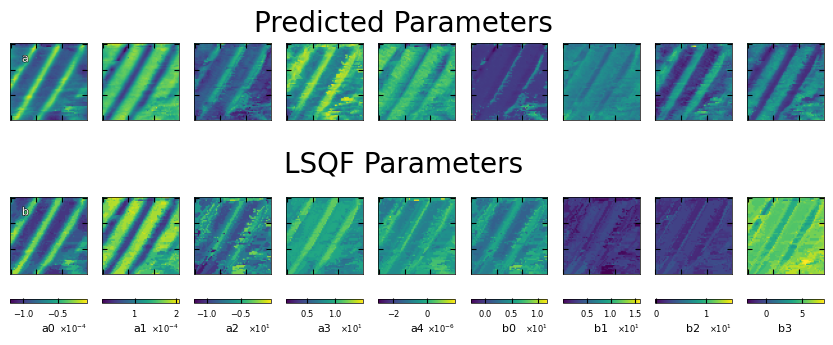

In [41]:
fig = BE_viz.hysteresis_maps(pred_params, cycle=0, filename="Figure_XX_NN_Hysteresis_Maps_test3")



[<Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: xlabel='a0'>,
 <Axes: xlabel='a1'>,
 <Axes: xlabel='a2'>,
 <Axes: xlabel='a3'>,
 <Axes: xlabel='a4'>,
 <Axes: xlabel='b0'>,
 <Axes: xlabel='b1'>,
 <Axes: xlabel='b2'>,
 <Axes: xlabel='b3'>]

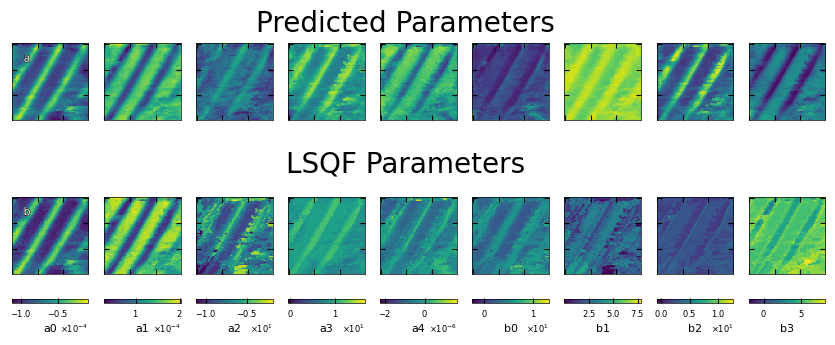

In [93]:
BE_viz.hysteresis_maps(pred_params, cycle=0, filename=None).get_axes()

In [64]:
fig.axes

[<Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: xlabel='a0'>,
 <Axes: xlabel='a1'>,
 <Axes: xlabel='a2'>,
 <Axes: xlabel='a3'>,
 <Axes: xlabel='a4'>,
 <Axes: xlabel='b0'>,
 <Axes: xlabel='b1'>,
 <Axes: xlabel='b2'>,
 <Axes: xlabel='b3'>]

In [96]:
5 //9

0

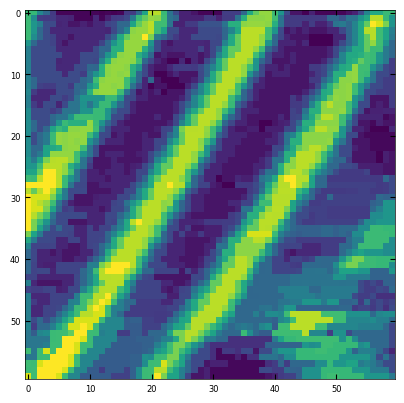

In [62]:

plt.imshow(fig.axes[9].images[0].get_array())

In [7]:
import pandas as pd
import seaborn as sns
import itertools
from torch import nn

from matplotlib.ticker import ScalarFormatter
#from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import EngFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter


from m3util.viz.layout import (
    layout_fig,
    add_box,
    inset_connector,
    scalebar,
    imagemap,
    FigDimConverter,
    subfigures,
    get_axis_pos_inches,
    draw_line_with_text,
)

from m3util.viz.text import (
    add_text_to_figure,
    set_sci_notation_label,
    labelfigs,
    obj_offset,
)




In [8]:
def y_formatter(y, pos):
    return f"{y * 1e3:.1f}"  # Multiply by 1e3 to show scaled values

def copy_axes_properties(row,col,source_ax, target_ax, secondary_ax, ax_lims):
    """Copy properties and data from source_ax to target_ax."""
    # Copy basic properties
    target_ax.set_xlim([-20,20])

    if row == 2: 
        target_ax.set_xlabel('Frequency (MHz)',fontsize=20)
    else:
        target_ax.set_xlabel("")
        target_ax.xaxis.set_ticklabels([])

    if col == 0:    
        target_ax.set_ylabel(source_ax.get_ylabel(),fontsize=20)
    else:
        target_ax.set_ylabel("")
        target_ax.yaxis.set_ticklabels([])

    target_ax.set_title(source_ax.get_title())

    # Copy lines from the primary axis
    for line in source_ax.get_lines():
        label = line.get_label() if line.get_label() != '_nolegend_' else None
        # Copying line properties like color, linestyle, marker, etc.
        target_ax.plot(line.get_xdata()/1e6, line.get_ydata(), color=line.get_color(),
                       linestyle=line.get_linestyle(), marker=line.get_marker(), label=label)
        
    # Handle twin axes if present
    #if secondary_ax:
    ax_twin = target_ax.twinx()
    ax_twin.set_ylim(secondary_ax.get_ylim())

    if col == 0: #if i % 2 == 0: 
        ax_twin.set_ylabel("")
        ax_twin.yaxis.set_ticklabels([])

        
        set_sci_notation_label(
                target_ax, corner="top left", axis="y", stroke_color="w", linewidth=0.5,
                textsize = 10, offset_points = (0,30)
            )
    else:
        ax_twin.set_ylabel(secondary_ax.get_ylabel(),fontsize = 20)
        ax_twin.set_yticks([-3,-2,-1,0,1,2,3])

    for line in secondary_ax.get_lines():
        label = line.get_label() if line.get_label() != '_nolegend_' else None
        # Copying line properties for the twin axis
        ax_twin.plot(line.get_xdata()/1e6, line.get_ydata(), color=line.get_color(),
                        linestyle=line.get_linestyle(), marker=line.get_marker(), label=label)

    target_ax.tick_params(axis='x',labelsize=20)
    target_ax.tick_params(axis='y',labelsize=20)
    if row == 0 and col == 0: 
        target_ax.yaxis.set_major_formatter(FuncFormatter(y_formatter))



    ax_twin.tick_params(axis='x',labelsize=20)

    ax_twin.tick_params(axis='y',labelsize=20)
    
    plt.tight_layout()

# Create a figure


No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


/tmp/ipykernel_2193813/1264522956.py:120: UserWarning: Adding colorbar to a different Figure <Figure size 2400x2400 with 3 Axes> than <Figure size 1050x400 with 27 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(inset_ax.images[0],


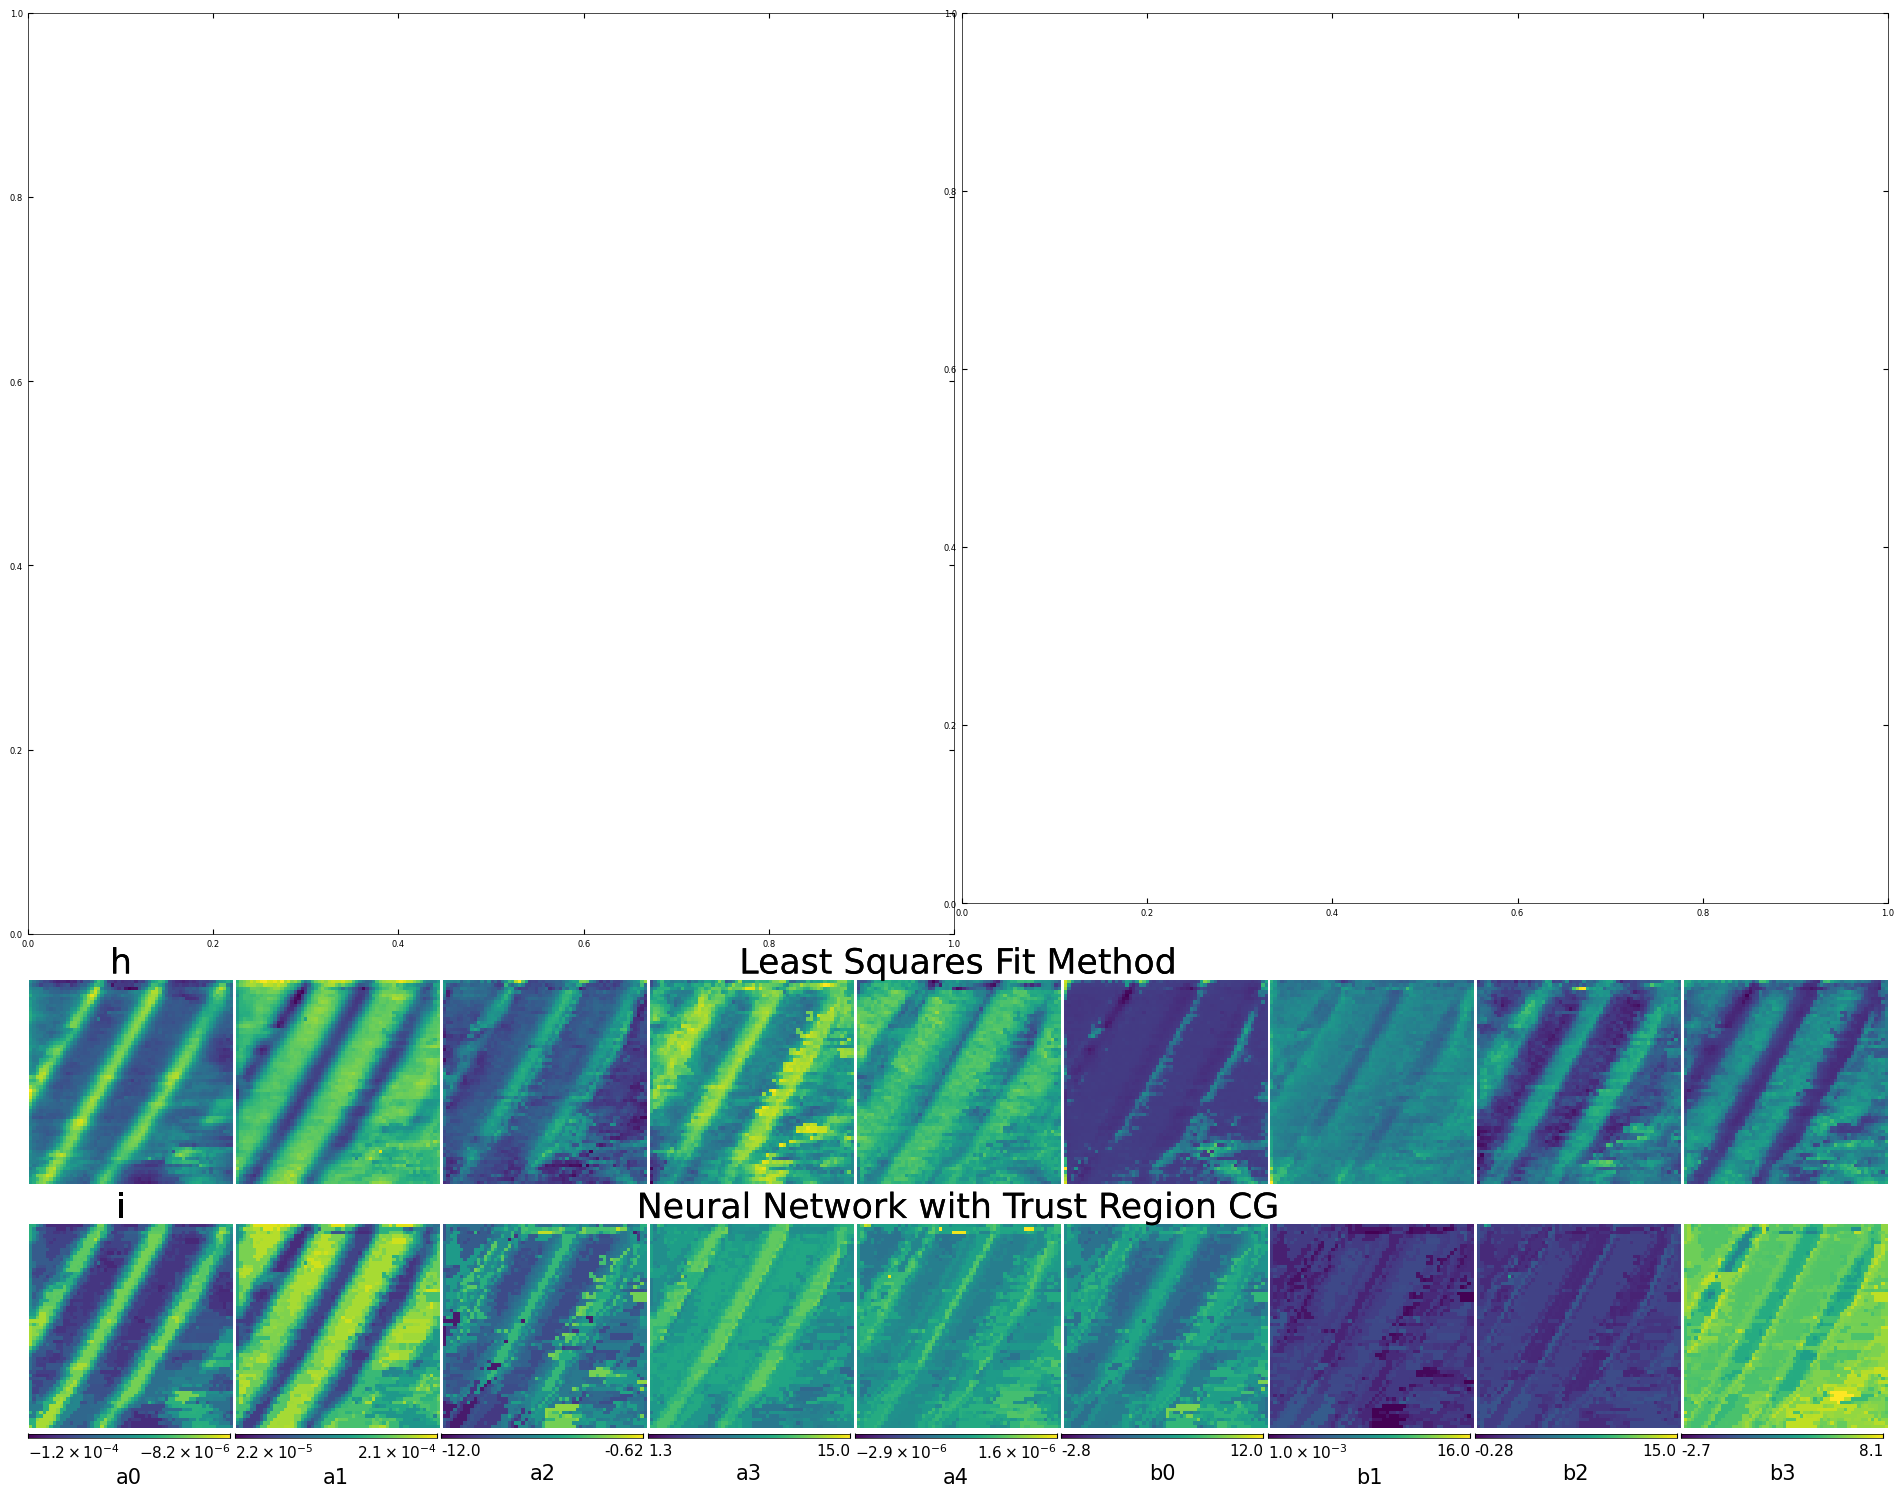

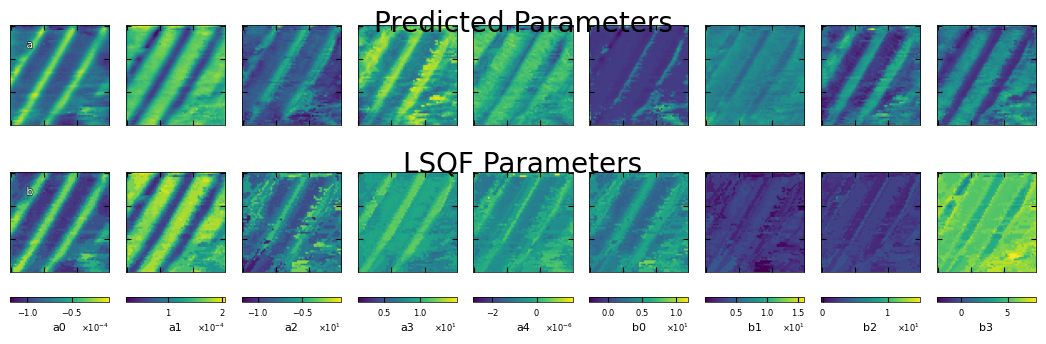

In [42]:
data, voltage = BE_viz.get_hysteresis(scaled=True, loop_interpolated = True)
data = torch.atleast_3d(torch.tensor(data.reshape(-1, 96)))

data_names = ("LSQF", "NN")

fig = plt.figure(figsize=(24, 24))


# Define the GridSpec layout
gs = GridSpec(60, 40, figure=fig)


order = [['NN_fit_comp'],
         ['violin'],
         ['switching_maps']
        ]

subplot_specs = [(0, 30, 0, 20 ), # top left: NN fit comparisons 
                 (0, 29, 20, 40), # g
                 (30, 46, 0, 60), #bottom 
                 (30, 36, 0, 6), #bottom row 1 col 1
                 (30, 36, 8, 14), #bottom row 1 col 2
                 (30, 36, 16, 22), #bottom row 1 col 3
                 (30, 36, 24, 30), #bottom row 1 col 4
                 (30, 36, 32, 38), #bottom row 1 col 5
                 (30, 36, 40, 46), #bottom row 1 col 6
                 (30, 36, 48, 54), #bottom row 1 col 7
                 (30, 36, 56, 62), #bottom row 1 col 8
                 (30, 36, 64, 70), #bottom row 1 col 9
                 
                 (40, 46, 0, 6), #bottom row 2 col 1
                 (40, 46, 8, 14), #bottom row 2 col 2
                 (40, 46, 16, 22), #bottom row 2 col 3
                 (40, 46, 24, 30), #bottom row 2 col 4
                 (40, 46, 32, 38), #bottom row 2 col 5
                 (40, 46, 40, 46), #bottom row 2 col 6
                 (40, 46, 48, 54), #bottom row 2 col 7
                 (40, 46, 56, 62), #bottom row 2 col 8
                 (40, 46, 64, 70), #bottom row 2 col 9
                ]

clims=[
                    (0, 1.4e-4),  # amplitude
                    (1.31e6, 1.33e6),  # resonance frequency
                    (-230, -160),  # quality factor
                    (-np.pi, np.pi), # phase
                ] 


renderViolin = False
renderHysteresisMaps = True
renderBMWComp = False

colorbar_labels = [
                    'a0', 'a1', 'a2', 'a3', 'a4', 'b0', 'b1', 'b2', 'b3'
                ]

for i, (r_start, r_end, c_start, c_end) in enumerate(subplot_specs):
    #if i < len(axes):
        try: 
            idx = order[i]
        except: 
            break
        ax = fig.add_subplot(gs[r_start:r_end, c_start:c_end])

        if idx[0] == 'violin':
            if renderViolin:
                BE_viz.violin_plot_comparison_hysteresis(model,
                                         torch.atleast_3d(torch.tensor(data.reshape(-1, 96))),
                                         filename=None,ax=ax) 

                # labels the figure and does some styling
                labelfigs(ax, string_add = 'g', loc ='tl',size=20, style="b", inset_fraction=(0.05,0.95))
                ax.set_ylabel("Scaled Hysteresis Results",fontsize=25)
                ax.set_xlabel("")
                
                ax.tick_params(axis='x',labelsize=20)
                ax.tick_params(axis='y',labelsize=20)

                # Get the legend associated with the plot
                legend = ax.get_legend()
                legend.set_title("")
                plt.setp(legend.get_texts(), fontsize=20) # Set the label size
        
        elif idx[0] == "switching_maps": 
            if renderHysteresisMaps:
               
                
                fig_hysteresis = BE_viz.hysteresis_maps(pred_params, cycle=0, filename=None);

                

                fig_scalar = FigDimConverter((1/2.5, 1/2.5))
                
                # def fmt(x, pos):
                #     a, b = '{:.1e}'.format(x).split('e')
                #     b = int(b)
                #     if abs(b) >2: 
                #         return r'${} \times 10^{{{}}}$'.format(a, b)
                    
                #     elif b==-1:
                #         return format(float(a)*10**b,".2f")
                #     else: 
                #         return float(a)*10**b
                

                for row in range(2):
                    for col in range(9):
                        inset_ax = ax.inset_axes([-0.153+(col/8.99),1-(row+1.2)/2.4-row/12,1/2.4,1/2.4])
                        inset_ax.imshow(fig_hysteresis.get_axes()[col+9*row].get_images()[0].get_array().data,cmap = 'viridis',
                                         vmin = BE_viz.hysteresis_maps_clims[col][0], vmax = BE_viz.hysteresis_maps_clims[col][1])
                        inset_ax.axis("off")
                        
                        if row == 1:
                            bar_ax = []
                            
                            pos_inch = [(col/22.5), -0.008, 1/23, 1/300  ] #fills axes
                            bar_ax.append(ax.inset_axes(fig_scalar.to_relative(pos_inch)))

                            cbar = plt.colorbar(inset_ax.images[0],      
                                                cax=bar_ax[0], format=FuncFormatter(fmt),orientation = 'horizontal',
                                                ticks = [BE_viz.hysteresis_maps_clims[col][0], BE_viz.hysteresis_maps_clims[col][1]])
                            
                            cbar.ax.get_xticklabels()[0].set_horizontalalignment('left')
                            cbar.ax.get_xticklabels()[1].set_horizontalalignment('right')

                            cbar.ax.tick_params(labelsize = 11)

                            
                            cbar.set_label(colorbar_labels[col],size=15,loc='center')  # Add a label to the colorbar
                            
                            
                    if row == 0: 
                        labelfigs(ax,
                                string_add="Least Squares Fit Method",
                                loc='tl',size=25,inset_fraction = (0.05,0.5),style='b',
                                horizontalalignment = 'center',verticalalignment='center')
                        labelfigs(ax,
                                string_add="h",
                                loc='tl',size=25,inset_fraction = (0.05,0.05),style='b',
                                horizontalalignment = 'left',verticalalignment='center')
                    else:
                        labelfigs(ax,
                                string_add="Neural Network with Trust Region CG",
                                loc='tl',size=25,inset_fraction = (0.55,0.5),style='b',
                                horizontalalignment = 'center',verticalalignment='center')
                        labelfigs(ax,
                                string_add="i",
                                loc='tl',size=25,inset_fraction = (0.55,0.05),style='b',
                                horizontalalignment = 'left',verticalalignment='center')
                        
                ax.axis("off")         
        else:
            if renderBMWComp:                
                ax.axis("off")
                size=(1.25, 1.25)
                gaps=(1, 0.66)
                fig_BMW = BE_viz.hysteresis_comparison(data_names, nn_model=model, filename=None)

                
             #   list_ax.append(axs)
                axes_index = [5,4,3,2,1,0]

                
                for row in range(3):
                    for col in range(2):
                        inset_ax = ax.inset_axes([(col/2)-col*0.05,1-(row+1)/3.2,1/3.2,1/3.2])
                                                
                        #inset_ax.set_xlim([-16,16])
                        inset_ax.set_xticks([-16,0,16])
                        if row == 2: 
                            inset_ax.set_xlabel('Voltage(V)', fontsize=20)
                        else:
                            inset_ax.set_xlabel("")
                            inset_ax.xaxis.set_ticklabels([])
                        if row == 0: 
                            inset_ax.set_ylim([-1.7e-4,1.5e-4])
                            inset_ax.set_yticks(np.linspace(-1.5e-4,1.5e-4,5))
                            if col == 1:
                                inset_ax.set_yticklabels("")
                        elif row == 1: 
                            inset_ax.set_ylim([-1.5e-4,1.2e-4])
                            inset_ax.set_yticks(np.linspace(-1.5e-4,1e-4,6))
                            if col == 1:
                                inset_ax.set_yticklabels("")
                        else:
                            inset_ax.set_ylim([-6e-4, 1e-4])
                            if col == 1:
                                inset_ax.set_yticklabels("")
                        
                        
                            
                        for line in fig_BMW.get_axes()[axes_index[2*row+col]].get_lines():
                        #for line in ax_hyst_comp[2*row+col].get_lines():
                            label = line.get_label() if line.get_label() != '_nolegend_' else None
                            # Copying line properties like color, linestyle, marker, etc.
                            inset_ax.plot(line.get_xdata(), line.get_ydata(), color=line.get_color(),
                                        linestyle=line.get_linestyle(), marker=line.get_marker(), label=label)
                            
                        if col==0:   
                            set_sci_notation_label(
                                inset_ax, corner="top left", axis="y", stroke_color="w", linewidth=0.5,
                                textsize = 10, offset_points = (0,30)
                            )
                        
                        
                        
                        inset_ax.tick_params(axis='x',labelsize=20)
                        inset_ax.tick_params(axis='y',labelsize=20)
                                    
                        plt.tight_layout()    
                        
                        
                        
                        if row == 0:
                        
                            labelfigs(inset_ax,
                                    string_add="Best",
                                    loc ='tl',
                                    size=15,
                                    inset_fraction=(0.05,0.37),
                                    style = 'b',
                                    horizontalalignment = "center"
                                    )
                            
                        # get legend handles and their corresponding labels
                            handles, labels = inset_ax.get_legend_handles_labels()
                            

                            inset_ax.legend(handles,labels, loc=(0.4,0.65),fontsize = 15)
                            

                        elif row == 1:
                            labelfigs(inset_ax,
                                    string_add="Median",
                                    loc ='tl',
                                    size=15,
                                    inset_fraction=(0.05,0.37),
                                    style = 'b',
                                    horizontalalignment = "center"
                                    )
                           
                        elif row == 2:
                            labelfigs(inset_ax,
                                    string_add="Worst",
                                    loc ='tl',
                                    size=15,
                                    inset_fraction=(0.05,0.37),
                                    style = 'b',
                                    horizontalalignment="center"
                                    )
                            ax.set_xticks([1.2,1.3,1.4])
                            
                        
                        labelfigs(inset_ax,
                            number=2*row+col,
                            loc ='tl',
                            size=15,
                            inset_fraction=(0.05,0.19),
                            style = 'b'
                            )


# Adjust the spacing between the plots as needed
plt.tight_layout()
                
# Show the layout
plt.show()

# BE_viz.printer.savefig(
#                 ax.figure, "Figure_4_test2"
#             )

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


/home/julian/BEPiezo-Learn/src/belearn/dataset/state.py:1141: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_example['Original Index'] = int(best_example['Original Index'])
/home/julian/BEPiezo-Learn/src/belearn/dataset/state.py:1144: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  worst_example['Original Index'] = int(worst_example['Original Index'])
/home/julian/BEPiezo-Learn/src/belearn/dataset/state.py:1147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returnin

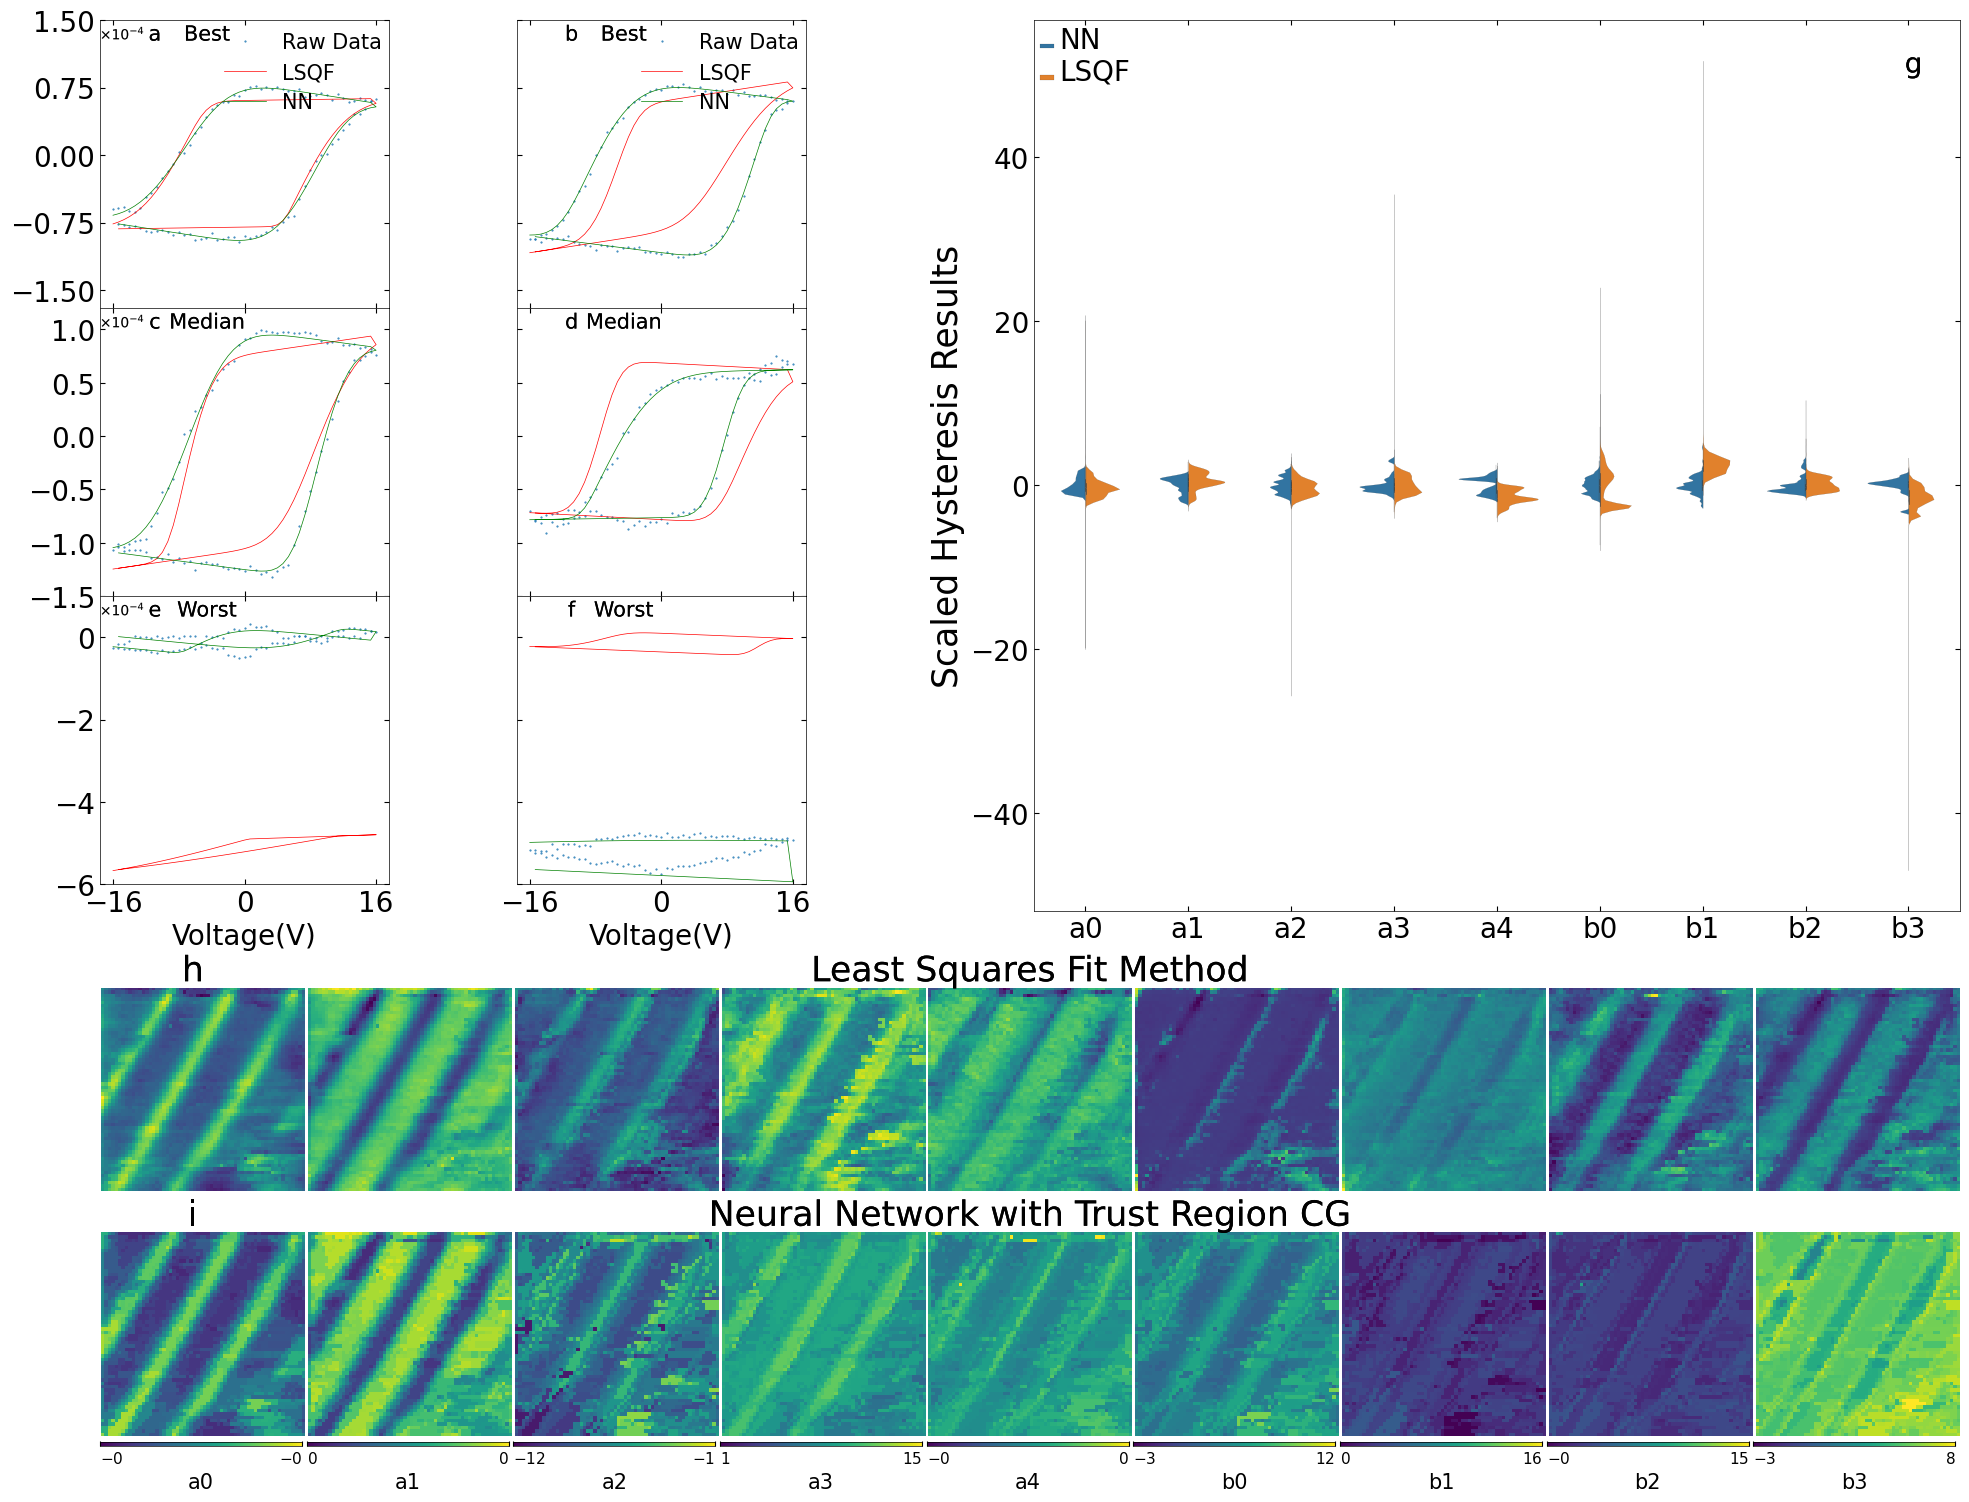

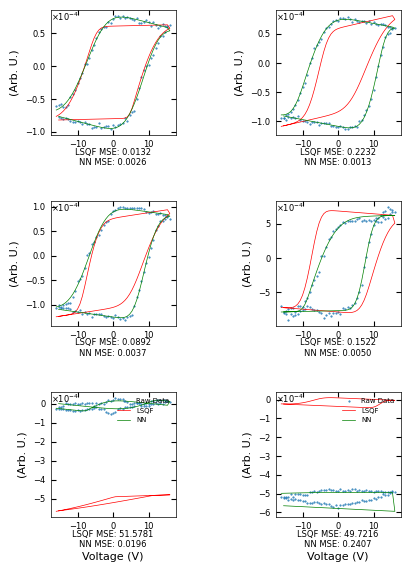

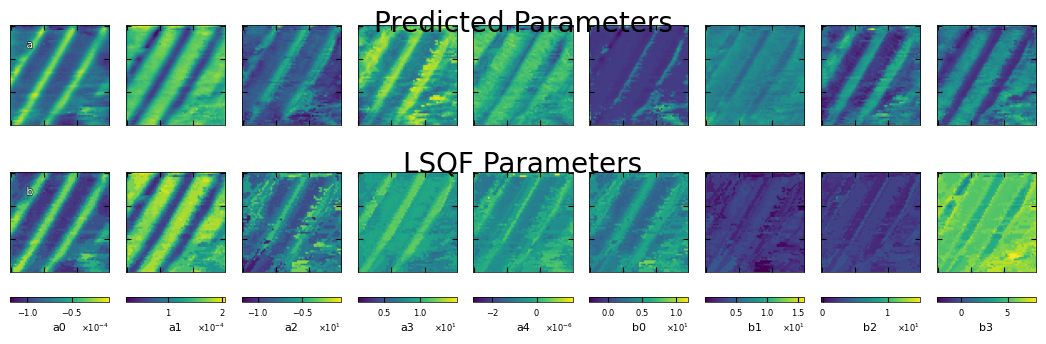

./Figures/Figure_4_func_2.png
./Figures/Figure_4_func_2.svg


In [73]:
BE_viz.plot_figure_4(model,pred_params,"Figure_4_func_2")

In [12]:
clims

NameError: name 'clims' is not defined

In [13]:
fig_scalar

NameError: name 'fig_scalar' is not defined

In [143]:
data

tensor([[[ 0.3089],
         [ 0.1603],
         [ 0.1098],
         ...,
         [-0.6803],
         [-0.6651],
         [-0.6515]],

        [[-0.7172],
         [-0.8387],
         [-0.7793],
         ...,
         [-0.6334],
         [-0.5495],
         [-0.5390]],

        [[ 0.2865],
         [ 0.3140],
         [ 0.3159],
         ...,
         [-0.8117],
         [-0.7958],
         [-0.7820]],

        ...,

        [[-0.9634],
         [-1.0170],
         [-0.9802],
         ...,
         [-0.8407],
         [-0.8662],
         [-0.9117]],

        [[-0.7887],
         [-0.7679],
         [-0.7291],
         ...,
         [-1.0134],
         [-0.9697],
         [-0.9828]],

        [[-0.9448],
         [-0.8975],
         [-0.9313],
         ...,
         [-0.9670],
         [-0.9519],
         [-0.9967]]], dtype=torch.float64)

In [117]:
order[2]

['switching_maps']

In [109]:
subplot_specs[0][2:4]

(0, 20)

In [111]:
gs[subplot_specs[0][0]:subplot_specs[0][1],subplot_specs[0][2]:subplot_specs[0][3]]

GridSpec(60, 40)[0:30, 0:20]

In [64]:
gs[subplot_specs[2][0]:subplot_specs[2][1],subplot_specs[2][2]:subplot_specs[2][3]]

GridSpec(60, 40)[30:46, 0:40]

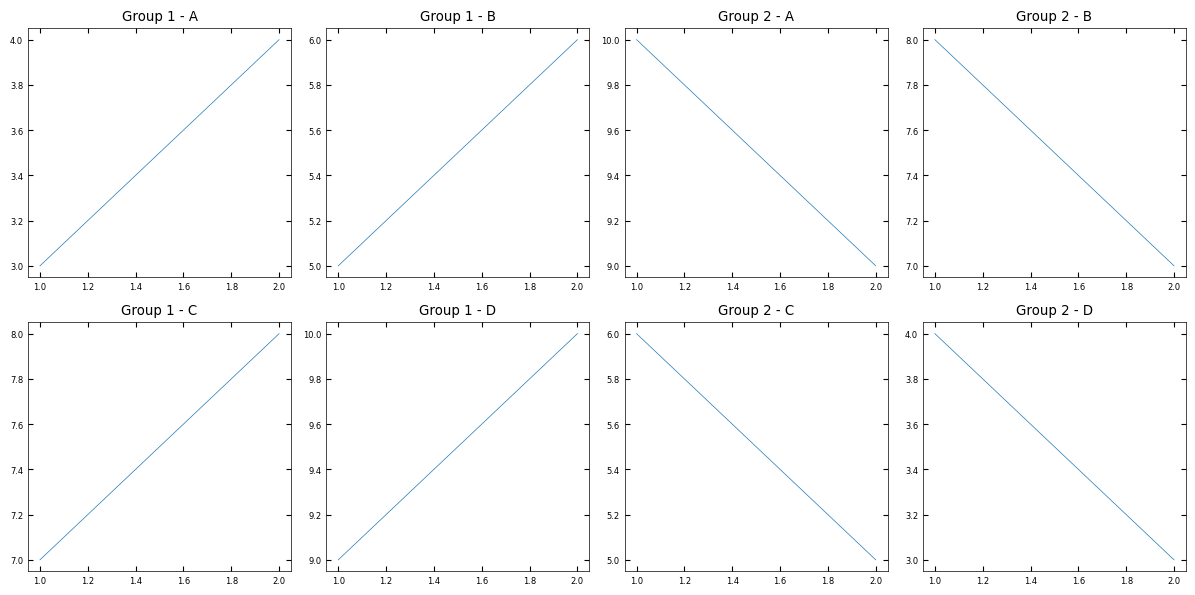

In [77]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_group(axs):
    axs[0][0].plot([1, 2], [3, 4])
    axs[0][0].set_title('Group 1 - A')
    axs[0][1].plot([1, 2], [5, 6])
    axs[0][1].set_title('Group 1 - B')
    axs[1][0].plot([1, 2], [7, 8])
    axs[1][0].set_title('Group 1 - C')
    axs[1][1].plot([1, 2], [9, 10])
    axs[1][1].set_title('Group 1 - D')

def plot_group2(axs):
    axs[0][0].plot([1, 2], [10, 9])
    axs[0][0].set_title('Group 2 - A')
    axs[0][1].plot([1, 2], [8, 7])
    axs[0][1].set_title('Group 2 - B')
    axs[1][0].plot([1, 2], [6, 5])
    axs[1][0].set_title('Group 2 - C')
    axs[1][1].plot([1, 2], [4, 3])
    axs[1][1].set_title('Group 2 - D')

def combine_all():
    fig = plt.figure(figsize=(12, 6))
    gs = gridspec.GridSpec(2, 4, figure=fig)

    # Allocate left 2x2 block
    ax1_00 = fig.add_subplot(gs[0, 0])
    ax1_01 = fig.add_subplot(gs[0, 1])
    ax1_10 = fig.add_subplot(gs[1, 0])
    ax1_11 = fig.add_subplot(gs[1, 1])
    axs_group1 = [[ax1_00, ax1_01], [ax1_10, ax1_11]]
    plot_group(axs_group1)

    # Allocate right 2x2 block
    ax2_00 = fig.add_subplot(gs[0, 2])
    ax2_01 = fig.add_subplot(gs[0, 3])
    ax2_10 = fig.add_subplot(gs[1, 2])
    ax2_11 = fig.add_subplot(gs[1, 3])
    axs_group2 = [[ax2_00, ax2_01], [ax2_10, ax2_11]]
    plot_group2(axs_group2)

    fig.tight_layout()
    return fig

fig = combine_all()
fig.show()


<Axes: title={'center': 'Plot 1'}>

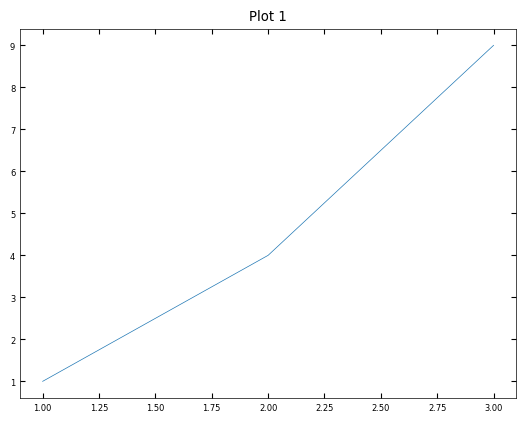

In [47]:
data1 = np.random.rand(100)
data2 = np.random.rand(100)
other_data = np.random.rand(100)


In [52]:
import matplotlib.pyplot as plt
import numpy as np

def regularPlot(subfig, data1, data2):
    """
    Builds a two-panel plot inside the provided subfigure.
    """
    axs = subfig.subplots(1, 2)
    axs[0].plot(data1)
    axs[0].set_title('Original Left')
    axs[0].set_xlabel('X Left')
    axs[0].set_ylabel('Y Left')

    axs[1].plot(data2)
    axs[1].set_title('Original Right')
    axs[1].set_xlabel('X Right')
    axs[1].set_ylabel('Y Right')

    subfig.suptitle('Original Inner Figure Title')

    return axs  # optionally return for further tweaks


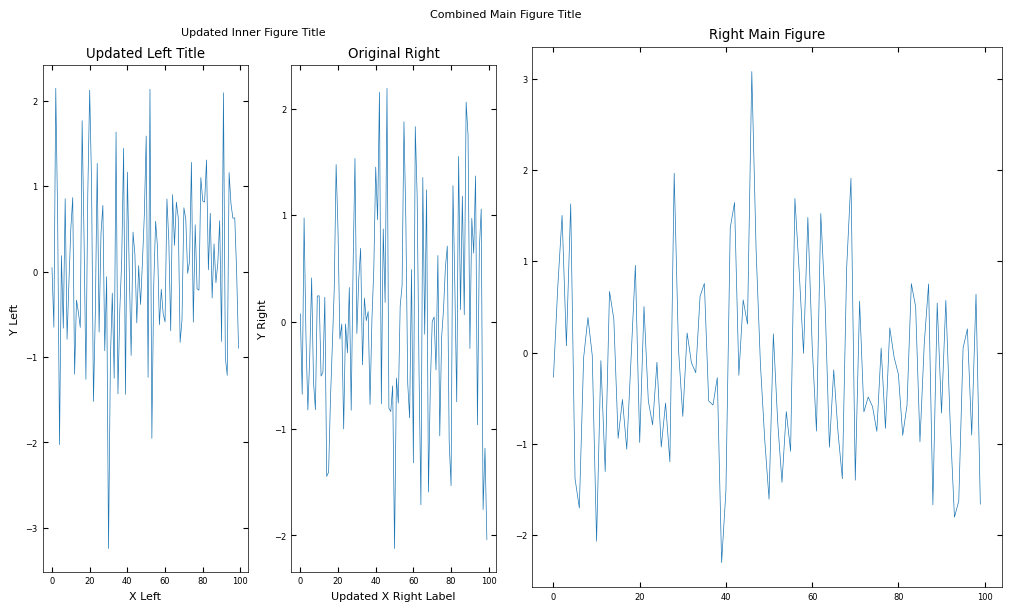

In [53]:
fig = plt.figure(constrained_layout=True, figsize=(10, 6))
subfigs = fig.subfigures(1, 2)

# Embed regularPlot into left subfigure
axs_inner = regularPlot(subfigs[0], np.random.randn(100), np.random.randn(100))

# Modify axis titles or labels AFTER embedding
axs_inner[0].set_title('Updated Left Title')
axs_inner[1].set_xlabel('Updated X Right Label')
subfigs[0].suptitle('Updated Inner Figure Title')

# Right side: some other plot
ax_right = subfigs[1].subplots()
ax_right.plot(np.random.randn(100))
ax_right.set_title('Right Main Figure')

fig.suptitle('Combined Main Figure Title')

plt.show()


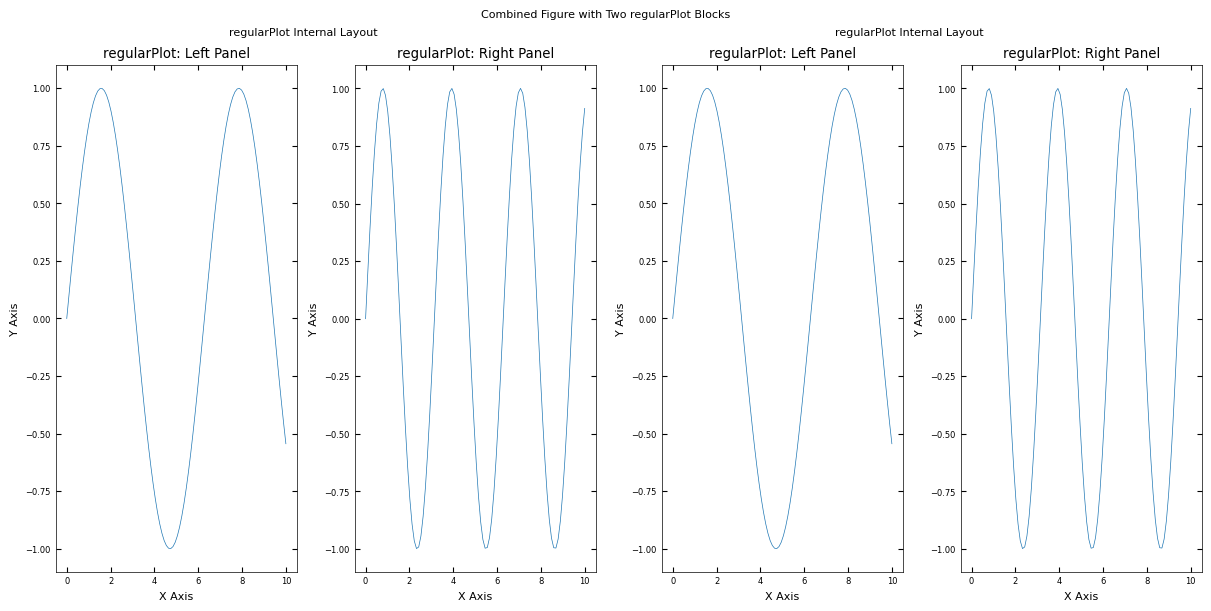

In [72]:
import matplotlib.pyplot as plt
import numpy as np

def regularPlot(x, parent_subfig=None):
    """
    Creates a 1x2 subplot layout.
    If parent_subfig is provided, plots inside it.
    Otherwise, creates its own figure and displays it.
    """
    if parent_subfig is None:
        # Standalone mode: create new figure directly
        fig, axs = plt.subplots(1, 2, figsize=(8, 4))
        show_plot = True
    else:
        # Combined mode: use provided subfigure
        axs = parent_subfig.subplots(1, 2)
        show_plot = False

    y1 = np.sin(x)
    y2 = np.sin(2 * x)

    axs[0].plot(x, y1)
    axs[0].set_title('regularPlot: Left Panel')
    axs[0].set_xlabel('X Axis')
    axs[0].set_ylabel('Y Axis')

    axs[1].plot(x, y2)
    axs[1].set_title('regularPlot: Right Panel')
    axs[1].set_xlabel('X Axis')
    axs[1].set_ylabel('Y Axis')

    if parent_subfig is not None:
        parent_subfig.suptitle('regularPlot Internal Layout')
    else:
        fig.suptitle('regularPlot Standalone Layout')

    if show_plot:
        plt.show()

    return axs

# ─── Example 1: Standalone regularPlot ─────────────────────────────
x = np.linspace(0, 10, 100)
#regularPlot(x)

# ─── Example 2: Combined figure with two regularPlot blocks ────────
fig = plt.figure(constrained_layout=True, figsize=(12, 6))
outer_gs = fig.add_gridspec(1, 2)

# Left block
subfig_left = fig.add_subfigure(outer_gs[0])
regularPlot(x, parent_subfig=subfig_left)

# Right block
subfig_right = fig.add_subfigure(outer_gs[1])
regularPlot(x, parent_subfig=subfig_right)

fig.suptitle('Combined Figure with Two regularPlot Blocks')

plt.show()
